In [1]:
import os
import sys
import pandas as pd

sys.path.append('/home/fboehning/fboehning')
#sys.path.append('C:/Users/felix/Documents/Studium Ingenieurinformatik/dAISY/fboehning')

#os.environ["WANDB_DISABLED"] = "true"  # Completely disables wandb
#sys.modules["wandb"] = None  # Prevent wandb from loading
# import wandb
# wandb.init()  # Will do nothing

In [2]:
# IMPORT: labtools
import labtools
from labtools.labhandler import *
from labtools.datahandle import *
from labtools.display_utils import *
from labtools.directory_utils import *
from labtools.dictionary_utils import *

set_display_for_dataframe()
pd.set_option('display.max_rows', 7)

In [3]:
# IMPORT: beesup_llm
# import beesup_llm
# import beesup_llm.toolkit.llm_utils; from beesup_llm.toolkit.llm_utils import *
# import beesup_llm.toolkit.dict_utils; from beesup_llm.toolkit.dict_utils import *
# import beesup_llm.toolkit.setup_utils; from beesup_llm.toolkit.setup_utils import *
# #import beesup_llm.toolkit.visualization; from beesup_llm.toolkit.visualization import *
# #import beesup_llm.toolkit.display_settings; from beesup_llm.toolkit.display_settings import *
# import beesup_llm.toolkit.retrieval_metrics; from beesup_llm.toolkit.retrieval_metrics import *


# import beesup_llm.dataset; from beesup_llm.dataset import *

#import beesup_llm.model_pipelines; from beesup_llm.model_pipelines import *
#import beesup_llm.finetuning_pipelines; from beesup_llm.finetuning_pipelines import *

#import beesup_llm.experiment; from beesup_llm.experiment import *

#import beesup_llm.injection.taxomizer; from beesup_llm.injection.taxomizer import *
#import beesup_llm.injection.rag_pipeline; from beesup_llm.injection.rag_pipeline import *
#import beesup_llm.injection.taxomizer_utils; from beesup_llm.injection.taxomizer_utils import * 
#import beesup_llm.injection.injection_experiment; from beesup_llm.injection.injection_experiment import *

import beesup_llm.llm; from beesup_llm.llm import *
import beesup_llm.emb; from beesup_llm.emb import *

import beesup_llm.injection; from beesup_llm.injection import *
import beesup_llm.injection.rag; from beesup_llm.injection.rag import *
import beesup_llm.injection.taxomizing; from beesup_llm.injection.taxomizing import *
import beesup_llm.injection.injection_evaluation; from beesup_llm.injection.injection_evaluation import *
import beesup_llm.injection.injection_experiment; from beesup_llm.injection.injection_experiment import *

In [4]:
import importlib
prefixpaths=['labtools','beesup_llm']

def get_modules_with_prefixpath(prefixpaths):
    if isinstance(prefixpaths, str):
        prefixpaths = [prefixpaths]

    modules=dict()
    all_modules = sys.modules.copy()
    for prefixpath in prefixpaths:
        for module_path, module in all_modules.items():
            if module_path.startswith(prefixpath):
                modules[module_path] = module

    return modules

def reimport(prefixpaths=prefixpaths):
    for module_path, module in get_modules_with_prefixpath(prefixpaths).items():
        importlib.reload(sys.modules[module_path])
        globals().update({name: getattr(module, name) for name in dir(module) if not name.startswith('_')})

LOGGING_FORMAT='%(asctime)s - %(filename)s - %(name)s - %(funcName)s - %(levelname)s - %(message)s'

import logging
logging.basicConfig(
    level=logging.INFO,
    format=LOGGING_FORMAT)

def set_info(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.INFO)
        logging.getLogger().setLevel(logging.INFO)

def set_debug(prefixpaths=prefixpaths):
    for module_path in get_modules_with_prefixpath(prefixpaths).keys():
        logger = logging.getLogger(module_path)
        logger.setLevel(logging.DEBUG)
        logging.getLogger().setLevel(logging.DEBUG)

set_info() 

In [ ]:
import wandb
wandb.login()
wandb.init(project="fboehning_beesup_injection", entity="mase-students", settings=wandb.Settings(init_timeout=90))

#WandbLogger

2025-02-19 14:01:18,922 - jupyter.py - wandb.jupyter - notebook_metadata - ERROR - Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: You can find your API key in your browser here: http://k8s.tu-ilmenau.de:31020/authorize
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for k8s.tu-ilmenau.de to your netrc file: /home/fboehning/.netrc
wandb: Currently logged in as: mase-students to http://k8s.tu-ilmenau.de:31020. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [5]:
#Load Model
llm_pipe=LlamaPipeline(1)
llm_pipe.prepare_inference()
model=copy.deepcopy(llm_pipe.get_model())

2025-03-13 07:55:57,084 - llm.py - labtools.labhandler - load_model - INFO - Loading model meta-llama/Meta-Llama-3.1-8B-Instruct
2025-03-13 07:55:57,885 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Prepare Data

## Base Data

In [8]:
import re
import spacy
import sqlite3

nlp=spacy.load('de_core_news_sm')

def count_words(text):
    text=re.sub(r'[(),-;]','',text) #normaly parentheses, commas and hyphens are counted as words --> remove them
    doc=nlp(text)
    return len(doc)

In [48]:
conn = sqlite3.connect('wildbienen_db.db')
query = """
WITH InfoQuery AS (
    -- First query (retrieving scientific names and associated attrs)
    SELECT
        t.name AS genus_species,
        ta.name AS author_year,
        it.name AS attr_key,
        i.value AS attr_val,
		s.name AS source_name,
		--s.base_url AS source_url,
		--i.source_other,
		it.type AS attr_type
		
	FROM information i	
    JOIN taxa t ON i.taxon_id = t.id
    JOIN info_types it ON i.type_id = it.id
    JOIN taxon_authors ta ON t.author_id = ta.id
    LEFT JOIN sources s ON i.source_id = s.id
	WHERE attr_key NOT IN (
		'Literatur', 'Literatur und Quellen', 'Quellen', 'Siehe auch', 'Belege', 
		'Weblinks', 'Weblink', 'Webseite', 'Einzelnachweise', 
		'Rote Liste BW:', 'Rote Liste D:',
		'Bilder', 'Bildergalerie',
		'Videos', 'Videoclips'
		)
		--AND genus_species in ('Andrena nitida', 'Andrena flavipes', 'Andrena nitidiuscula')
),

VernacularNames AS (
    -- Second query (retrieving vernacular names for German and English where the scientific name matches InfoQuery)
    SELECT
        t.name AS genus_species,
        ta.name AS author_year,
        'Deutscher Name:' AS attr_key,
        tv.name AS attr_val,
        'wildbienen-kataster' AS source_name,           
		'Attribute' AS attr_type

		
    FROM taxa t
    JOIN taxon_vernacularnames tv ON t.id = tv.taxon_id
    JOIN taxon_authors ta ON t.author_id = ta.id
    WHERE tv.language_code = 'de'
    AND t.name IN (SELECT genus_species FROM InfoQuery)

)

-- Final query to combine InfoQuery and VernacularNames
SELECT * FROM InfoQuery

UNION

SELECT * FROM VernacularNames

ORDER BY genus_species, attr_key, attr_val;

"""

query_df = pd.read_sql_query(query, conn)
conn.close()

query_df['attr_key']=query_df['attr_key'].apply(lambda x: re.sub(r': *$', '', x))
query_df['attr_val']=query_df['attr_val'].apply(lambda x: x.strip())

query_df['author_year']=query_df['author_year'].apply(lambda x: re.sub(r'[()]', '', x))
query_df['attr_val']=query_df.apply(lambda x: f'{x.genus_species} ({x.author_year})' if x.attr_key=='Wissenschaftlicher Name' else x.attr_val, axis=1)

query_df.replace('', np.nan, inplace=True)
query_df.dropna(inplace=True)

query_df.loc[query_df.attr_key=='Deutscher Name','attr_key']='Umgangssprachliche Bezeichnungen'
query_df.loc[query_df.attr_key=='Kuckucksbiene','attr_key']='Kuckucksbienen'
query_df.loc[query_df.attr_key=='Kuckuckswespe','attr_key']='Kuckuckswespen'
query_df.loc[query_df.attr_key=='Wirtsbiene','attr_key']='Wirtsbienen'

query_df=query_df[query_df.attr_val!='']
query_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text
1,Aglaoapis tridentata,"Nylander, 1848",Umgangssprachliche Bezeichnungen,Dunkle Zweizahnbiene,wildbienen-kataster,Attribute
2,Aglaoapis tridentata,"Nylander, 1848",Umgangssprachliche Bezeichnungen,Zweizahnbiene,wildbienen-kataster,Attribute
3,Aglaoapis tridentata,"Nylander, 1848",Familie,Megachilidae,wildbienen-kataster,Attribute
4,Aglaoapis tridentata,"Nylander, 1848",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text
...,...,...,...,...,...,...
4301,Xylocopa violacea,"Linnaeus, 1758",Nistweise,hypergäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute
4302,Xylocopa violacea,"Linnaeus, 1758",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute
4303,Xylocopa violacea,"Linnaeus, 1758",Requisiten,Totholz,wildbienen-kataster,Attribute
4304,Xylocopa violacea,"Linnaeus, 1758",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text


In [ ]:
base_df=query_df.groupby(by=['genus_species','author_year','attr_key']).agg({
    'attr_val': lambda x: '; '.join(x),
    'source_name': lambda x: x.iloc[0],
    'attr_type': lambda x: x.iloc[0],
    #'n_tokns':'sum',

}).reset_index()

base_df['n_units']=query_df.groupby(by=['genus_species','author_year','attr_key']).size().values
base_df['n_words']=base_df['attr_val'].apply(count_words)

base_df['scientific_name']=base_df['genus_species']+' ('+base_df['author_year']+')'
#base_df.to_pickle('wildbienen_df.pkl')
base_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type,n_units,n_words,scientific_name
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"Aglaoapis tridentata (Nylander, 1848)"
1,Aglaoapis tridentata,"Nylander, 1848",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"Aglaoapis tridentata (Nylander, 1848)"
2,Aglaoapis tridentata,"Nylander, 1848",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"Aglaoapis tridentata (Nylander, 1848)"
3,Aglaoapis tridentata,"Nylander, 1848",Lebensraum,"Die Biene lebt auf trockenen, blütenreichen Bö...",wikipedia,Text,1,38,"Aglaoapis tridentata (Nylander, 1848)"
4,Aglaoapis tridentata,"Nylander, 1848",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"Aglaoapis tridentata (Nylander, 1848)"
...,...,...,...,...,...,...,...,...,...
3884,Xylocopa violacea,"Linnaeus, 1758",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute,1,1,"Xylocopa violacea (Linnaeus, 1758)"
3885,Xylocopa violacea,"Linnaeus, 1758",Requisiten,Totholz,wildbienen-kataster,Attribute,1,1,"Xylocopa violacea (Linnaeus, 1758)"
3886,Xylocopa violacea,"Linnaeus, 1758",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"Xylocopa violacea (Linnaeus, 1758)"
3887,Xylocopa violacea,"Linnaeus, 1758",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"Xylocopa violacea (Linnaeus, 1758)"


In [11]:
base_df=pd.read_pickle('wildbienen_df.pkl')
base_df

,genus_species,author_year,attr_key,attr_val,source_name,attr_type,n_units,n_words,scientific_name
0,Aglaoapis tridentata,"Nylander, 1848",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"Aglaoapis tridentata (Nylander, 1848)"
...,...,...,...,...,...,...,...,...,...
3888,Xylocopa violacea,"Linnaeus, 1758",Wissenschaftlicher Name,"Xylocopa violacea (Linnaeus, 1758)",wildbienen-kataster,Attribute,1,3,"Xylocopa violacea (Linnaeus, 1758)"


In [21]:
reimport()

In [17]:
datah=BaseDatahandle(
    label='wildbienen_database',
    data_df=base_df,
    remarks='querried from wildbienen.db, preprocessed',
)
datah.config
datah.save()

## Embedding Data

In [13]:
reimport()

In [14]:
emb_pipe=NVEmbedPipeline(instruction='Instruct: Given a passage, retrieve a suitable header\n\n\nPassage:\n\n')
#emb_pipe=NVEmbedPipeline(instruction='Retrieve a suitable header')
emb_pipe.config

{'id': 1,
 'label': 'NVEmbedPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
 'module_path': 'beesup_llm.emb',
 'name_or_path': 'nvidia/NV-Embed-v2',
 'instruction': 'Instruct: Given a passage, retrieve a suitable header\n\n\nPassage:\n\n'}

In [17]:
EMB_TEMPLATES={
    "s":"{s}",
    "p":"{p}",
    "o":"{o}",
    "spo":"{s}\n\n{p}\n\n{o}",
    "po":"{p}\n\n{o}",
    "so":"{s}\n\n{o}",
}

emb_pipe.prepare()
base_dh=BaseDatahandle(-1)
emb_df=base_dh.df.copy()

emb_df=emb_df.drop(columns=['genus_species','author_year'])
emb_df=emb_df.rename(columns={
    'scientific_name':'s',
    'attr_key':'p',
    'attr_val':'o',
})
col_order=['s','p','o','source_name','attr_type','n_units','n_words']
emb_df=emb_df[col_order]

for key in EMB_TEMPLATES.keys():
    print(f'{key}' + 20*' ', end='\n')

    if key not in emb_df.columns:
        emb_df[key]=emb_df.apply(lambda x:EMB_TEMPLATES[key].format(**x),axis=1)

    emb_pipe.add_emb(
        emb_df,
        txt_key=key,
        emb_key=f'{key}_emb',
        verbose=True
        )

emb_df.to_pickle('emb_df.pkl')

s                    
p                               
o                             
spo                               
po                                
so                                


In [28]:
emb_df=pd.read_pickle('emb_df.pkl')
emb_df

,s,p,o,source_name,attr_type,n_units,n_words,s_emb,p_emb,o_emb,spo,spo_emb,po,po_emb,so,so_emb
0,"Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.014767954, -0.018229043, -0.0016549958, -0....","[0.008440343, 0.045302227, 0.028917862, -0.005...","[0.01933271, -0.005132632, -0.004533985, -0.01...","Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","[0.01965355, -0.006788069, 0.00045000107, -0.0...","Aussehen\n\nDie Biene ist schwarz, etwa 8–10 m...","[0.0168985, -0.00018723025, 0.0028166026, -0.0...","Aglaoapis tridentata (Nylander, 1848)\n\nDie B...","[0.021416044, -0.00743316, -0.002379829, -0.01..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3888,"Xylocopa violacea (Linnaeus, 1758)",Wissenschaftlicher Name,"Xylocopa violacea (Linnaeus, 1758)",wildbienen-kataster,Attribute,1,3,"[0.015408109, -0.0054594674, -0.02533482, 0.01...","[0.009134908, 0.026007697, -0.010826476, -0.00...","[0.015269403, -0.0054677636, -0.025276378, 0.0...","Xylocopa violacea (Linnaeus, 1758)\n\nWissensc...","[0.020580081, 0.0008819187, -0.02421862, 0.010...",Wissenschaftlicher Name\n\nXylocopa violacea (...,"[0.017811617, 0.00040411673, -0.023888398, 0.0...","Xylocopa violacea (Linnaeus, 1758)\n\nXylocopa...","[0.017409183, 0.0040994007, -0.028355267, 0.01..."


In [ ]:
datah=EmbeddingDatahandle(
    data_df=emb_df,
    remarks='s,p,o emb variations'
)
datah.emb_templates=EMB_TEMPLATES
datah.base_dh=base_dh.config
datah.emb_pipe_config=emb_pipe.config
datah.config
#datah.save()

## Chunk Data

In [32]:
# CREATE chunks_df

def get_first_n_words(text, n=2):
    return ' '.join(re.split(r'[\s,;]',text)[:n])

def compose_emb(row):
    s,p,o,so,po,spo=[row[f'{c}_emb'] for c in ['s','p','o','so','po','spo']]

    if row.attr_type=='Text':
        emb=po
    elif row.attr_type=='Attribute':
        emb=po

    # weights = np.array([0.0, 0.25, 0.75]) 
    # emb = np.average(np.array([s,p,o]), axis=0, weights=weights)
    #emb=spo-s
    #emb=po

    emb_normalized=emb/ np.linalg.norm(emb) #normalize
    return emb_normalized

emb_dh=EmbeddingDatahandle(-1)
emb_df=emb_dh.df
chunks_df=emb_df.copy()
chunks_df=chunks_df[chunks_df.p!='Wissenschaftlicher Name'].copy()
chunks_df['emb']=chunks_df.apply(compose_emb, axis=1)
chunks_df=chunks_df[['spo','s','p','o','source_name','attr_type','n_units','n_words','emb']].copy()
chunks_df['label']=chunks_df.apply(lambda x: f"{get_first_n_words(x.p, n=4)}/ {get_first_n_words(x.o, n=10)}", axis=1)

DROP_EMB_DUPLICATES=False
if DROP_EMB_DUPLICATES:
    chunks_df['emb_tuple']=chunks_df['emb'].apply(tuple)
    grouped = chunks_df.groupby('emb_tuple', group_keys=False).apply(lambda group: list(group.index), include_groups=False).reset_index(name='kidc')
    chunks_df = pd.merge(chunks_df, grouped, on='emb_tuple', how='left')
    chunks_df.drop_duplicates(subset='emb_tuple',keep='first',inplace=True)
    chunks_df.drop(columns=['emb_tuple'],inplace=True)
else:
    chunks_df = chunks_df.reset_index(names='kidx')

chunks_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...
...,...,...,...,...,...,...,...,...,...,...,...
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...


In [34]:
datah=ChunksDatahandle(
    data_df=chunks_df,
    remarks='emb = po_emb, excluded rows with p="Wissenschaftlicher Name" ',
)

datah.drop_emb_duplicates=DROP_EMB_DUPLICATES
datah.emb_dh=emb_dh.config
datah.config
datah.save()

In [9]:
reimport()

### RAG Chunk Data

In [ ]:
emb_pipe=NVEmbedPipeline(instruction='')
#emb_pipe=NVEmbedPipeline(instruction='Retrieve a suitable header')
emb_pipe.config


{'id': 1,
 'label': 'NVEmbedPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
 'module_path': 'beesup_llm.emb',
 'name_or_path': 'nvidia/NV-Embed-v2',
 'instruction': ''}

In [14]:
emb_dh=EmbeddingDatahandle(-1)
emb_df=emb_dh.df
chunks_df=emb_df.copy()
chunks_df=chunks_df[chunks_df.p!='Wissenschaftlicher Name'].copy()
chunks_df=chunks_df[['spo','s','p','o','source_name','attr_type','n_units','n_words']].copy()

emb_pipe(chunks_df, txt_key='spo', emb_key='emb', verbose=True)
chunks_df

2025-03-11 13:39:05,534 - emb.py - labtools.labhandler - load_model - INFO - Loading model nvidia/NV-Embed-v2
2025-03-11 13:39:08,045 - modeling.py - accelerate.utils.modeling - get_balanced_memory - INFO - We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

,spo,s,p,o,source_name,attr_type,n_units,n_words,emb
0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.012748182, -0.008126336, 0.0070746336, -0.0..."
...,...,...,...,...,...,...,...,...,...
3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.02273562, -0.00811959, 0.0067524533, -0.000..."


In [16]:
chunks_df.to_pickle('chunks_df.pkl')

In [18]:
ChunksDatahandle(-1).df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...
...,...,...,...,...,...,...,...,...,...,...,...
3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...


In [21]:
reimport()

In [24]:
datah=ChunksDatahandle(
    label='RAG_CHUNKS',
    data_df=chunks_df,
    remarks='emb = spo_emb, excluded rows with p="Wissenschaftlicher Name" ',
)

datah.emb_pipe=emb_pipe.config
datah.config
datah.save()

# Taxomizer

In [8]:
reimport()

In [42]:
Datahandle().get_overview(keypaths=['remarks','n_rows','columns','name_or_path','instruction'])

,class_parts,id,label,remarks,n_rows,columns,name_or_path,instruction
0,[Datahandle],1,base,"querried from wildbienen.db, without embs",3889,"genus_species, author_year, attr_key, attr_val...",NaN,NaN
1,[Datahandle],2,raw_triples,NaN,3889,"s, p, o, source_name, attr_type, n_units, n_words",NaN,NaN
2,[Datahandle],3,emb_triples,"s,p,o emb variations",3889,"s, p, o, source_name, attr_type, n_units, n_wo...",nvidia/NV-Embed-v2,Retrieve a suitable header
3,[Datahandle],4,emb_chunks,"emb = po_emb, excluded rows with p=""Wissenscha...",3412,"kidx, spo, s, p, o, source_name, attr_type, n_...",NaN,NaN
4,"[Datahandle, BaseDatahandle]",1,wildbienen_database,"querried from wildbienen.db, preprocessed",3889,"genus_species, author_year, attr_key, attr_val...",NaN,NaN
5,"[Datahandle, EmbeddingDatahandle]",1,emb_triples,"s,p,o emb variations",3889,"s, p, o, source_name, attr_type, n_units, n_wo...",nvidia/NV-Embed-v2,Retrieve a suitable header
6,"[Datahandle, ChunksDatahandle]",1,po_chunks,"emb = po_emb, excluded rows with p=""Wissenscha...",3412,"kidx, spo, s, p, o, source_name, attr_type, n_...",nvidia/NV-Embed-v2,Retrieve a suitable header


In [ ]:
chunks_dh=ChunksDatahandle(-1)

taxomizer=Taxomizer(
    dist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=1.0),
    ddist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std=False, std_factor=1.0),
    chunks_df=chunks_dh,
    llm_pipe=LlamaPipeline(1),
    )

taxomizer.chunks_dh=chunks_dh.config
taxomizer.config
#taxomizer.save()

In [ ]:
reimport()

In [ ]:
taxomizer=Taxomizer(-1)
taxomizer.config

use_kneepoint=True

taxomizer.dist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std= not use_kneepoint, std_factor=1.0)
taxomizer.ddist_flattening_config=dict(include_leaves=False, use_kneepoint=True, use_std= not use_kneepoint, std_factor=1.0)
taxomizer.config

{'id': 1,
 'label': 'Taxomizer',
 'lab_name': 'injection_lab',
 'class_parts': ['Taxomizer'],
 'module_path': 'beesup_llm.injection.taxomizing',
 'chunk_txt_key': 'spo',
 'chunk_emb_key': 'emb',
 'linkage_args': {'method': 'ward', 'optimal_ordering': False},
 'dist_flattening_config': {'include_leaves': True,
  'use_kneepoint': True,
  'use_std': False,
  'std_factor': 1.0},
 'ddist_flattening_config': {'include_leaves': True,
  'use_kneepoint': True,
  'use_std': False,
  'std_factor': 1.0},
 'tree_info': {'bin_tree': {'num_nodes': 6823,
   'height': 203,
   'num_root_children': 2,
   'num_leaves': 3412,
   'branching': 2.0,
   'avg_degree': 1.0,
   'avg_balance': 6.94,
   'dia': 324,
   'avg_depth': 24.52,
   'width': 664},
  'dist_threshold': 0.6411620230809789,
  'dist_tree': {'num_nodes': 3515,
   'height': 11,
   'num_root_children': 2,
   'num_leaves': 3412,
   'branching': 34.43,
   'avg_degree': 1.0,
   'avg_balance': 0.04,
   'dia': 21,
   'avg_depth': 6.69,
   'width': 760},

2025-03-11 07:23:49,468 - taxomizing_utils.py - root - linkage_to_btree - INFO - {'num_nodes': 6823, 'height': 203, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 2.0, 'avg_degree': 1.0, 'avg_balance': 6.94, 'dia': 324, 'avg_depth': 24.52, 'width': 664}
2025-03-11 07:23:50,468 - taxomizing_utils.py - root - get_dist_kneepoint - INFO - knee_dist: 0.6412, knee_index: 6720/ 6823


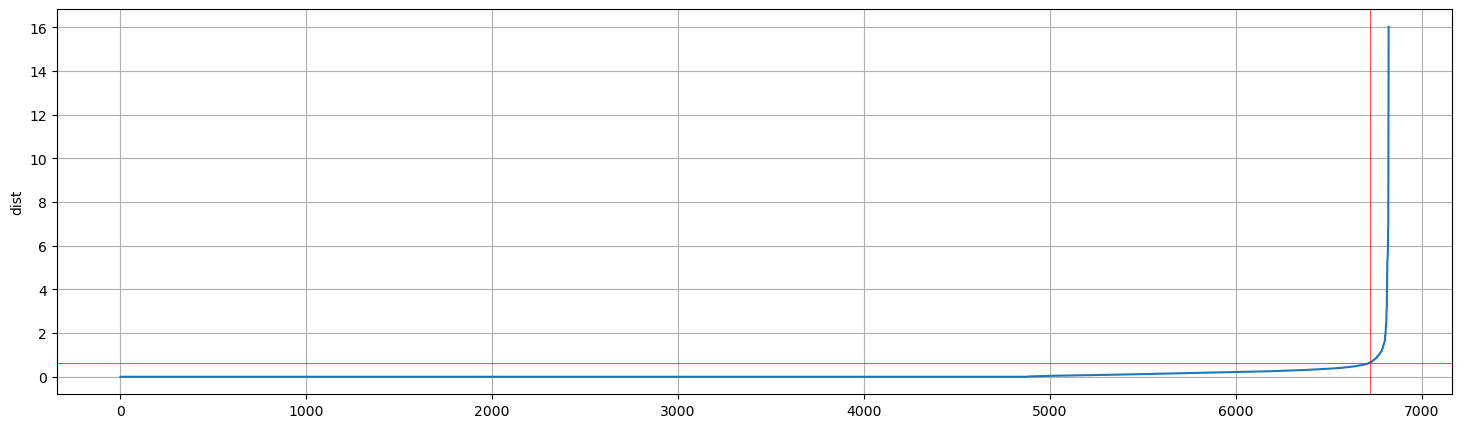

2025-03-11 07:23:50,872 - taxomizing_utils.py - root - do_dist_flattening - INFO - {'num_nodes': 3515, 'height': 11, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 34.43, 'avg_degree': 1.0, 'avg_balance': 0.04, 'dia': 21, 'avg_depth': 6.69, 'width': 760}
2025-03-11 07:23:51,097 - taxomizing_utils.py - root - get_ddist_kneepoint - INFO - knee_ddist: 1.7024, knee_index: 3500/ 3514


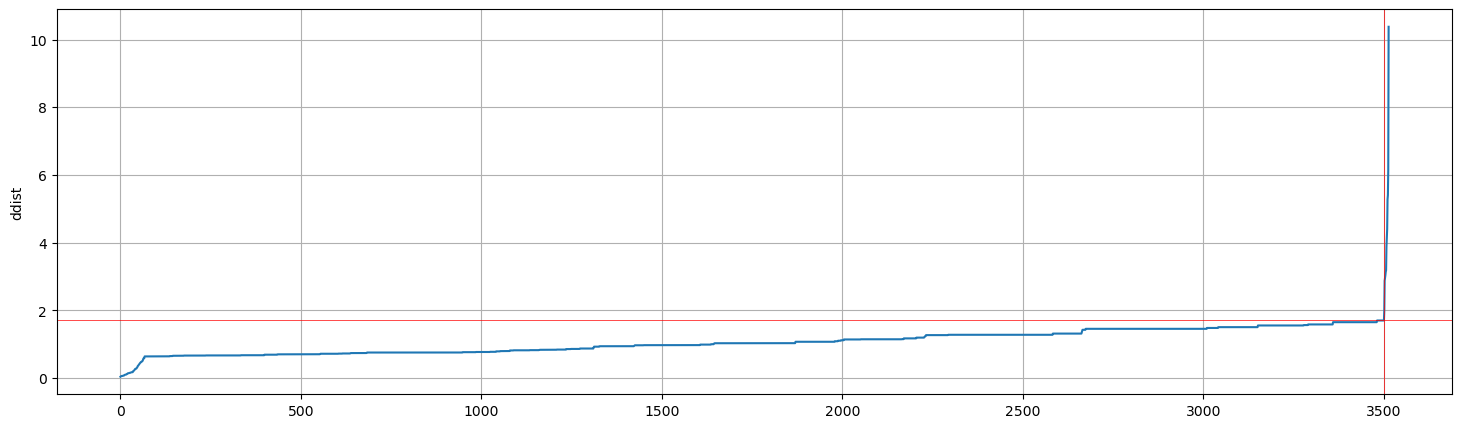

2025-03-11 07:23:51,393 - taxomizing_utils.py - root - do_ddist_flattening - INFO - {'num_nodes': 3439, 'height': 6, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 132.15, 'avg_degree': 1.0, 'avg_balance': 0.0, 'dia': 10, 'avg_depth': 4.43, 'width': 1392}
2025-03-11 07:23:51,452 - taxomizing_utils.py - root - recover_leaf_parents - INFO - {'num_nodes': 3440, 'height': 6, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 127.3, 'avg_degree': 1.0, 'avg_balance': 0.0, 'dia': 10, 'avg_depth': 4.5, 'width': 1392}


3412, 

In [32]:
taxomizer.process_until_ddist_tree(plot=True)

In [36]:
tree_data=[]
pd.set_option('display.max_rows', 10)
for k, v in taxomizer.tree_info.items():
    
    if isinstance(v, dict):
        tree_dict=dict(tree=k)
        tree_dict.update(v)
        tree_data.append(tree_dict)

tree_df=pd.DataFrame(tree_data)
tree_df

,tree,num_nodes,height,num_root_children,num_leaves,branching,avg_degree,avg_balance,dia,avg_depth,width
0,bin_tree,6823,203,2,3412,2.00,1.0,6.94,324,24.52,664
1,dist_tree,3515,11,2,3412,34.43,1.0,0.04,21,6.69,760
2,ddist_tree_raw,3439,6,2,3412,132.15,1.0,0.00,10,4.43,1392
3,ddist_tree_rec,3440,6,2,3412,127.30,1.0,0.00,10,4.50,1392


In [11]:
taxomizer=Taxomizer(-1, model=model)
taxomizer.config

{'id': 1,
 'label': 'Taxomizer',
 'lab_name': 'injection_lab',
 'class_parts': ['Taxomizer'],
 'module_path': 'beesup_llm.injection.taxomizing',
 'chunk_txt_key': 'spo',
 'chunk_emb_key': 'emb',
 'linkage_args': {'method': 'ward', 'optimal_ordering': False},
 'dist_flattening_config': {'include_leaves': False,
  'use_kneepoint': True,
  'use_std': False,
  'std_factor': 1.0},
 'ddist_flattening_config': {'include_leaves': False,
  'use_kneepoint': True,
  'use_std': False,
  'std_factor': 1.0},
 'chunks_dh': {'id': 2,
  'label': 'ChunksDatahandle',
  'lab_name': 'injection_lab',
  'class_parts': ['Datahandle', 'ChunksDatahandle'],
  'module_path': 'labtools.datahandle',
  'drop_emb_duplicates': False,
  'emb_dh': {'id': 2,
   'label': 'EmbeddingDatahandle',
   'lab_name': 'injection_lab',
   'class_parts': ['Datahandle', 'EmbeddingDatahandle'],
   'module_path': 'labtools.datahandle',
   'emb_templates': {'s': '{s}',
    'p': '{p}',
    'o': '{o}',
    'spo': '{s}\n\n{p}\n\n{o}',
    '

In [12]:
taxomizer.process(verbose=True)

2025-03-11 12:13:53,514 - taxomizing_utils.py - root - linkage_to_btree - INFO - {'num_nodes': 6823, 'height': 121, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 2.0, 'avg_degree': 1.0, 'avg_balance': 4.36, 'dia': 231, 'avg_depth': 20.12, 'width': 632}
2025-03-11 12:13:54,188 - taxomizing_utils.py - root - get_dist_kneepoint - INFO - knee_dist: 0.8682, knee_index: 3357/ 3411
2025-03-11 12:13:54,544 - taxomizing_utils.py - root - do_dist_flattening - INFO - {'num_nodes': 3466, 'height': 9, 'num_root_children': 2, 'num_leaves': 3412, 'branching': 65.34, 'avg_degree': 1.0, 'avg_balance': 0.01, 'dia': 18, 'avg_depth': 5.73, 'width': 1197}
2025-03-11 12:13:55,018 - taxomizing_utils.py - root - get_ddist_kneepoint - INFO - knee_ddist: 2.1418, knee_index: 41/ 53
2025-03-11 12:13:55,244 - taxomizing_utils.py - root - do_ddist_flattening - INFO - {'num_nodes': 3435, 'height': 6, 'num_root_children': 3, 'num_leaves': 3412, 'branching': 155.95, 'avg_degree': 1.0, 'avg_balance': 0.0, 'd

3412, 1/24                                        
2/24                                                                       
3/24                                                                       
4/24                                                                       
5/24                                                                     
6/24                                                                     
7/24                                                                     
8/24                                                                     
9/24                                                                     
10/24                                                                    
11/24                                                                    
12/24                                                                      
13/24                                                                     
14/24                                               

2025-03-11 12:15:30,527 - taxomizing.py - labtools.labhandler - load_emb_tree - INFO - all chunks included in the tree: True


[6822] Wildbienen
├──  [6820] Umgangssprachliche Bezeichnungen für Wildbienen
│   ├──  [6791] Umgangssprachliche Bezeichnungen für Wildbienen-Arten
│   └──  [6818] Kuckucksbienen (Nomaden)
│       ├──  [6801] Familien der Kuckucksbienen (Nomaden)
│       └──  [6814] Kuckucksbienen (Nomaden)
│           ├──  [6809] Gattung Nomada
│           └──  [6810] Kuckucksbienen (Nomaden) - Liste der Wirtsbienen
│               ├──  [3412] Kuckucksbienen (Nomaden) - Liste der Wirtsbienen
│               ├──  [6773] Wirtsbienen: Liste der Arten
│               └──  [6777] Parasiten der Wildbienen
├──  [6816] Lebensweise und Merkmale von Wildbienen
│   ├──  [6797] Merkmale der Wildbienen
│   └──  [6813] Lebensweise und Nestbau
│       ├──  [6802] Nestbau und Neststruktur
│       ├──  [6794] Vorkommen und Lebensweise von Wildbienen-Parasiten
│       └──  [6800] Verbreitung und Lebensraum
└──  [6819] Nist- und Pollenökologie
    ├──  [6808] Nistplatzmorphologie
    ├──  [6786] Pollensammelverhalten: V

In [ ]:
from beesup_llm.injection.taxomizing_plot import get_plot_for_taxomizer_tree
fig=get_plot_for_taxomizer_tree(Taxomizer(-1).emb_tree)

In [43]:
print(taxomizer.get_table_of_contents())

 Wildbienen
├──  Lebensweise und Merkmale der Sandbienen
│   ├──  Nestbau und Nahrungssammlung
│   ├──  Merkmale der Sandbienen
│   ├──  Bienenarten der Familie Apidae
│   ├──  Hummelarten in Deutschland
│   ├──  Taxonomie und Systematik der Sandbienen
│   └──  Vorkommen und Lebensweise der Sandbienen
└──  Umgangssprachliche Bezeichnungen für Wildbienen
    ├──  Nist- und Pollenquellen von Wildbienen
    │   ├──  Nistorten von Wildbienen
    │   ├──  Pollensammelverhalten
    │   ├──  Sozialverhalten von Wildbienen
    │   └──  Nist- und Pollenquellen von Wildbienen: natürliche und künstliche Nistplätze
    └──  Umgangssprachliche Bezeichnungen für Wildbienen-Arten
        ├──  Familien der Wildbienen
        ├──  Umgangssprachliche Bezeichnungen für Wildbienen-Arten
        └──  Kuckuckswespen



# Create Injection Dataset

- also consider finetuning not in chat-format
- provide whole table of content in system instruction?
- multiple queries in one conversation (alternating masking required)
- consider entitie-swap.. genus species (author, year) --> german synonym 
- include source in the query prompt .. "What does wikipedia write about _predicate_ of _subject_?"

In [43]:
pd.set_option('display.max_rows', 5)
taxomizer_df=Taxomizer().get_overview(keypaths=['tree_info.ddist_tree_rec.branching','tree_info.ddist_tree_rec.height','tree_info.ddist_tree_rec.width'])
taxomizer_df

,class_parts,id,label,branching,height,width
0,[Taxomizer],1,Taxomizer,149.22,6,1647


In [64]:
# INSTRUCTION PROMPTING
def get_n_words_str(n_words:int, lang='de') -> str:
    n_words_str=None

    if lang=='de':
        if n_words==1: n_words_str='einem Wort'
        elif n_words==2: n_words_str='zwei Wörtern'
        elif n_words==3: n_words_str='drei Wörtern'
        elif n_words==4: n_words_str='vier Wörtern'
        elif n_words==5: n_words_str='fünf Wörtern'
        elif n_words < 10: n_words_str='weniger als zehn Wörtern'
        elif n_words < 20: n_words_str='weniger als zwanzig Wörtern'
        else:
            n_words_str=f'etwa {round(n_words, -1)} Wörtern'
    
    if lang =='en':
        if n_words==1: n_words_str='one word'
        elif n_words==2: n_words_str='two words'
        elif n_words==3: n_words_str='three words'
        elif n_words==4: n_words_str='four words'
        elif n_words==5: n_words_str='five words'
        elif n_words < 10: n_words_str='less than ten words'
        elif n_words < 20: n_words_str='less than twenty words'
        else:
            n_words_str=f'approximately {round(n_words, -1)} words'
    
    return n_words_str

def get_system_prompt(toc:str=None, **kwargs) -> str:
    prompt=""
    prompt+="""
You are a knowledge-oriented AI assistant specialised in wild bee knowledge. \
You provide factual knowledge about the user's input in the style of a lexicon entry, without any additional commentary, conversational language, or speculation. \
You only respond in German, using single words or brief descriptions like in an encyclopedia. \
""".strip()
    if toc:
        prompt+="\n\nYour wild-bee knowledge is organized in the following knowledge-tree:\n"
        prompt+=f"{toc}"

    return prompt
    
def get_query_prompt(p:str, s:str, n_words:int, toc_until:str=None, **kwargs) -> str:
    prompt=""

    if toc_until is not None:
        prompt+=f"Innerhalb des Knowledge Tree befinden wir uns an folgender Stelle:\n"
        prompt+=f"{toc_until}\n"

    prompt+=f"Was weißt du über die Eigenschaft '{p}' von {s}? "
    prompt+=f"Antworte mit {get_n_words_str(n_words, lang='de')}!"

    return prompt

def get_prompt_messages(sample) -> list:
    prompt_messages=[]
    prompt_messages.append({'role':'system','content':get_system_prompt(**sample)})
    prompt_messages.append({'role':'user','content':get_query_prompt(**sample)})

    return prompt_messages


In [ ]:
# Create Injection dataset
USE_TAXONOMY=True

if USE_TAXONOMY:
    taxomizer=Taxomizer(-1)
    injection_df=taxomizer.df
    llm_tree=taxomizer.llm_tree
else:
    chunks_dh=ChunksDatahandle(2)
    toc=None
    injection_df=chunks_dh.df

if USE_TAXONOMY:

    toc_dict=dict()
    hpath_dict=dict()
    for node_id in injection_df.node_id.unique():
        the_node=get_node(node_id, llm_tree)
        hpath_dict[node_id]=get_headerpath_until(the_node,llm_tree)
        toc_dict[node_id]=get_table_of_contents(get_tree_branch_until(the_node, llm_tree))

    injection_df['toc']=len(injection_df)*[taxomizer.toc]
    injection_df['toc_until']=injection_df.node_id.map(toc_dict)
    injection_df['hpath']=injection_df.node_id.map(hpath_dict)

injection_df['prompt_messages']=injection_df.apply(lambda x: get_prompt_messages(x), axis=1)
injection_df['gold_message']=injection_df['o'].apply(lambda x: [{'role':'assistant','content':x}])
injection_df.reset_index(drop=False, names='tidx', inplace=True) #preserve taxomizer index as tidx
injection_df

,tidx,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,node_id,toc,toc_until,hpath,prompt_messages,gold_message
0,0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.0168985, -0.00018723025, 0.0028166026, -0.0...",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,6797,Wildbienen\n├── Umgangssprachliche Bezeichnu...,Wildbienen\n└── Lebensweise und Merkmale von...,"[Wildbienen, Lebensweise und Merkmale von Wild...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Die Biene i..."
1,1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.002335957, -0.012015877, 0.015676783, 0.00...",Familie/ Megachilidae,6801,Wildbienen\n├── Umgangssprachliche Bezeichnu...,Wildbienen\n└── Umgangssprachliche Bezeichnu...,"[Wildbienen, Umgangssprachliche Bezeichnungen ...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Megachilida..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,3410,3886,"Xylocopa violacea (Linnaeus, 1758)\n\nUmgangss...","Xylocopa violacea (Linnaeus, 1758)",Umgangssprachliche Bezeichnungen,Blauschwarze Holzbiene; Große Holzbiene,wildbienen-kataster,Attribute,2,4,"[0.01527659, 0.021630187, 0.004161036, -0.0011...",Umgangssprachliche Bezeichnungen/ Blauschwarze...,6791,Wildbienen\n├── Umgangssprachliche Bezeichnu...,Wildbienen\n└── Umgangssprachliche Bezeichnu...,"[Wildbienen, Umgangssprachliche Bezeichnungen ...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Blauschwarz..."
3411,3411,3887,"Xylocopa violacea (Linnaeus, 1758)\n\nVorkomme...","Xylocopa violacea (Linnaeus, 1758)",Vorkommen,Die Art kommt in Süd- und Mitteleuropa bis in ...,wikipedia,Text,1,162,"[0.019412424, -0.000282465, 0.017827231, 0.001...",Vorkommen/ Die Art kommt in Süd- und Mitteleur...,6800,Wildbienen\n├── Umgangssprachliche Bezeichnu...,Wildbienen\n└── Lebensweise und Merkmale von...,"[Wildbienen, Lebensweise und Merkmale von Wild...","[{'role': 'system', 'content': 'You are a know...","[{'role': 'assistant', 'content': 'Die Art kom..."


In [66]:
use_cols=['kidx','tidx','prompt_messages','gold_message']

if USE_TAXONOMY: use_cols+=['toc','toc_until','node_id','hpath']

injection_df=injection_df[use_cols].copy()
#injection_df=injection_df.sample(10)
injection_df['split']='train'

datah=InjectionDatahandle(
    data_df=injection_df,
    remarks='english system prompt, german query prompt',
)

datah.use_taxonomy=USE_TAXONOMY
if USE_TAXONOMY:
    datah.taxomizer=taxomizer.config
else:
    datah.chunks_dh=chunks_dh.config

datah.config
datah.save()

# Evaluators/ Evaluation Questions

In [23]:
pd.set_option('display.max_rows', 10)
Datahandle().get_overview(keypaths=['n_rows','remarks','tax_config','split'])

,class_parts,id,label,n_rows,remarks
0,[Datahandle],1,base,3889,"querried from wildbienen.db, without embs"
1,[Datahandle],2,raw_triples,3889,NaN
2,[Datahandle],3,emb_triples,3889,"s,p,o emb variations"
3,[Datahandle],4,emb_chunks,3412,"emb = po_emb, excluded rows with p=""Wissenscha..."
4,"[Datahandle, BaseDatahandle]",1,wildbienen_database,3889,"querried from wildbienen.db, preprocessed"
...,...,...,...,...,...
6,"[Datahandle, EmbeddingDatahandle]",2,EmbeddingDatahandle,3889,"s,p,o emb variations"
7,"[Datahandle, ChunksDatahandle]",1,po_chunks,3412,"emb = po_emb, excluded rows with p=""Wissenscha..."
8,"[Datahandle, ChunksDatahandle]",2,ChunksDatahandle,3412,"emb = po_emb, excluded rows with p=""Wissenscha..."
9,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,3412,"english system prompt, german query prompt"


In [77]:
injection_dh=InjectionDatahandle(-1)

if injection_dh.use_taxonomy:
    chunks_dh=ChunksDatahandle(injection_dh.taxomizer['chunks_dh']['id'])
else:
    chunks_dh=ChunksDatahandle(injection_dh.chunks_dh['id'])

emb_dh=EmbeddingDatahandle(chunks_dh.emb_dh['id'])
emb_df=emb_dh.df
emb_cols=[c for c in emb_df.columns if c.endswith('_emb')]
print(f"{emb_cols=}")

chunks_df=chunks_dh.df
chunks_df=chunks_df.merge(emb_df[emb_cols], left_on='kidx', right_index=True, how='left')
chunks_df

emb_cols=['s_emb', 'p_emb', 'o_emb', 'spo_emb', 'po_emb', 'so_emb']


,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,s_emb,p_emb,o_emb,spo_emb,po_emb,so_emb
0,0,"Aglaoapis tridentata (Nylander, 1848)\n\nAusse...","Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.011508312, -0.006344277, -0.0052704075, -0....",Aussehen/ Die Biene ist schwarz etwa 8–10 mm ...,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[0.005372163, 0.027560156, 0.027903788, 0.0050...","[0.012666877, -0.008224907, -0.0023187273, -0....","[0.007820462, -0.014049686, 0.0025894884, -0.0...","[0.011508312, -0.006344277, -0.0052704075, -0....","[0.010986259, -0.017528981, -0.0003686533, -0...."
1,1,"Aglaoapis tridentata (Nylander, 1848)\n\nFamil...","Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[-0.007887345, -0.0066592945, 0.013873018, 0.0...",Familie/ Megachilidae,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[-0.013899579, 0.010438204, 0.027639559, 0.004...","[-0.013556923, 0.0041819816, 0.018591344, 0.01...","[0.002152701, -0.023951797, 0.0049711, -0.0022...","[-0.007887345, -0.0066592945, 0.013873018, 0.0...","[-0.00014541276, -0.021814719, 0.0053975685, -..."
2,2,"Aglaoapis tridentata (Nylander, 1848)\n\nKurzb...","Aglaoapis tridentata (Nylander, 1848)",Kurzbeschreibung,"Dunkle Zweizahnbiene (Aglaoapis tridentata, Sy...",wikipedia,Text,1,23,"[0.007456032, -0.020963887, 0.024268383, -0.00...",Kurzbeschreibung/ Dunkle Zweizahnbiene (Aglaoa...,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[0.010904431, 0.0067367004, 0.017549247, 0.010...","[0.00514163, -0.021301871, 0.029156908, -0.003...","[0.0011278308, -0.016686134, 0.019786855, -0.0...","[0.007456032, -0.020963887, 0.024268383, -0.00...","[0.001274398, -0.018167993, 0.02211455, -0.010..."
3,3,"Aglaoapis tridentata (Nylander, 1848)\n\nLeben...","Aglaoapis tridentata (Nylander, 1848)",Lebensraum,"Die Biene lebt auf trockenen, blütenreichen Bö...",wikipedia,Text,1,38,"[0.008907344, 0.007084162, 0.0232829, -0.00735...",Lebensraum/ Die Biene lebt auf trockenen blüt...,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[-0.006125478, 0.022764863, 0.015483949, 0.012...","[0.0052229767, 0.005738662, 0.0243119, -0.0041...","[0.009938083, -0.008536287, 0.02288715, -0.010...","[0.008907344, 0.007084162, 0.0232829, -0.00735...","[0.008845769, -0.008988842, 0.021815522, -0.01..."
4,4,"Aglaoapis tridentata (Nylander, 1848)\n\nSozia...","Aglaoapis tridentata (Nylander, 1848)",Sozialverhalten,parasitisch,wildbienen-kataster,Attribute,1,1,"[0.0056375368, 0.010362302, 0.021358192, 0.008...",Sozialverhalten/ parasitisch,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[0.014847353, 0.020165756, 0.03291362, 0.00568...","[-0.004300288, 0.014256915, 0.012839905, 0.018...","[0.00486948, -0.004038323, 0.018164914, 0.0052...","[0.0056375368, 0.010362302, 0.021358192, 0.008...","[0.008787484, -0.010138204, 0.0091767935, 0.00..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3407,3883,"Xylocopa violacea (Linnaeus, 1758)\n\nNistweis...","Xylocopa violacea (Linnaeus, 1758)",Nistweise,hypergäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,1,2,"[-0.0005679256, 0.0016991013, 0.031325415, 0.0...",Nistweise/ hypergäisch-selbstgegrabene Hohlräume,"[0.0074653667, -8.167466e-05, -0.022661159, 0....","[0.008146713, 0.011654212, 0.035470545, 0.0084...","[-0.0030062557, 0.009253301, 0.01900182, 0.015...","[0.0076342467, -0.010947353, -0.0012420228, 0....","[-0.00056792557, 0.0016991012, 0.03132541, 0.0...","[0.008623026, -0.0026039926, -0.005147396, 0.0..."
3408,3884,"Xylocopa violacea (Linnaeus, 1758)\n\nPollensa...","Xylocopa violacea (Linnaeus, 1758)",Pollensammelverhalten,polylektisch,wildbienen-kataster,Attribute,1,1,"[0.0035197109, -0.0025032656, 0.021665998, -0....",Pollensammelverhalten/ polylektisch,"[0.0074653667, -8.167466e-05, -0.022661159, 0....","[0.010422551, 0.0081292465, 0.023295106, 0.009...","

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

def fetch_similar_samples(sample: dict, samples_df: pd.DataFrame, emb_key:str='spo_emb') -> pd.DataFrame:
    if not emb_col.endswith('_emb'): emb_col=f"{emb_key}_emb"

    sample_embs=np.vstack(samples_df[emb_col].values)
    sample_emb=sample[emb_col]

    match_matrix=cosine_similarity(sample_emb.reshape(1,-1),sample_embs)[0]

    similar_df=samples_df[['kidx','tidx','s','p','o']].copy()
    similar_df['score']=match_matrix
    
    similar_df.sort_values(by='score',ascending=False,inplace=True)
    similar_df=similar_df[similar_df.kidx!=sample.kidx].copy()
    similar_df.reset_index(drop=True,inplace=True)
    return similar_df

def add_sample(sample:dict, path: str) -> pd.DataFrame:
    samples_df=pd.read_pickle(path)
    samples_df=pd.concat([samples_df, pd.DataFrame([sample])], ignore_index=True)
    samples_df.to_pickle(path)
    return samples_df

## MCQ Evaluator

### generate multiple choice questions

In [79]:
import random

def get_mcq_generation_prompt(sample,samples_df, emb_col=None):

    CHUNK_TEMPLATE="{s}\t{p}\t{o}"
    get_mcq_generation_prompt.add_kidc=[]
    
    add_chunks=False
    if sample.attr_type=='Attribute': add_chunks=True

    if emb_col is None: emb_col=random.choice(['s','p','o','so','po','spo'])
    get_mcq_generation_prompt.emb_col=emb_col
    
    prompt=""
    prompt+="Create a multiple-choice question that tests the understanding of the following knowledge chunk. "
    prompt+="Ensure the question is clear, concise, and relevant to the key knowledge in the chunk. "
    prompt+="Provide four answer options, with one correct answer and three plausible but incorrect wrong choices."
    if add_chunks:
        prompt+=" I also will provide some additional knowledge chunks that you can use to make up the wrong choices. "
        prompt+="But the main focus lies on the knowledge chunk initially provided."
    
    prompt+="\n\n"
    prompt+="""
Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated question in German",
    "right_choice": "the correct answer",
    "wrong_choices": ["first wrong answer", "second wrong answer", "third wrong answer"] # List of three wrong answer options
}
""".strip()
    
    prompt+="\n\n"

    if add_chunks: prompt+="### MAIN KNOWLEDGE-CHUNK:\n\n"
    else: prompt+="### KNOWLEDGE-CHUNK:\n\n"
    prompt+=CHUNK_TEMPLATE.format(**sample)+'\n\n'

    if add_chunks:
        similar_df=fetch_similar_samples(sample, samples_df, emb_col=emb_col)

        prompt+="### ADDITIONAL KNOWLEDGE-CHUNKS:\n\n"
        chars, max_chars = 0, 600
        for i,similar_sample in similar_df.iterrows():
            line=CHUNK_TEMPLATE.format(**similar_sample)+'\n\n'
            prompt+=line
            chars+=len(line)
            get_mcq_generation_prompt.add_kidc.append(similar_sample.kidx)
            if chars>max_chars: break
            if i>4: break
    
    prompt+="### QUESTION:\n"

    return prompt


In [80]:
new_samples_df=chunks_df.sample(100, random_state=None).copy()
new_samples_df.reset_index(drop=True, inplace=True)
new_samples_df

,kidx,spo,s,p,o,source_name,attr_type,n_units,n_words,emb,label,s_emb,p_emb,o_emb,spo_emb,po_emb,so_emb
0,2465,"Lasioglossum rufitarse (Zetterstedt, 1838)\n\n...","Lasioglossum rufitarse (Zetterstedt, 1838)",Nistweise,endogäisch-selbstgegrabene Hohlräume,wildbienen-kataster,Attribute,1,2,"[-0.0039245957, 0.011581014, 0.030884946, 0.00...",Nistweise/ endogäisch-selbstgegrabene Hohlräume,"[0.009374881, 0.015772019, -0.0017278605, 0.00...","[0.008146713, 0.011654212, 0.035470545, 0.0084...","[-0.0035949643, 0.006670998, 0.023050888, 0.01...","[0.0057799825, 0.013653506, 0.011386788, 0.004...","[-0.0039245957, 0.011581014, 0.030884946, 0.00...","[0.008276946, 0.019533107, 0.011328161, 0.0061..."
1,1352,"Ceratina chalybea (Chevrier, 1872)\n\nNistweis...","Ceratina chalybea (Chevrier, 1872)",Nistweise,hypergäisch-markhaltige Stängel,wildbienen-kataster,Attribute,1,2,"[0.013233388, 0.00025031046, 0.0328769, 0.0095...",Nistweise/ hypergäisch-markhaltige Stängel,"[-0.014623201, -0.005465174, 0.0054708654, 0.0...","[0.008146713, 0.011654212, 0.035470545, 0.0084...","[0.009005068, 0.0062261503, 0.02393413, 0.0111...","[0.0007340585, -0.007014466, 0.022205306, -0.0...","[0.013233388, 0.00025031046, 0.0328769, 0.0095...","[-0.00023072906, -0.0029259615, 0.022532389, -..."
2,1063,"Bombus cullumanus (Kirby, 1802)\n\nLebensraum ...","Bombus cullumanus (Kirby, 1802)",Lebensraum und Verbreitung,Die Cullumanushummel bevorzugt kalkreiche Blum...,wikipedia,Text,1,65,"[0.022899065, -0.0061472147, 0.027642995, -0.0...",Lebensraum und Verbreitung/ Die Cullumanushumm...,"[0.005253717, -0.010141071, -0.0059315083, -0....","[0.023947243, 0.02056919, 0.008765363, -0.0080...","[0.022774452, -0.003587015, 0.028795978, 0.002...","[0.019703615, -0.007860144, 0.023660636, -0.01...","[0.022899065, -0.0061472147, 0.027642995, -0.0...","[0.0209078, -0.0073900647, 0.026049528, -0.010..."
3,3,"Aglaoapis tridentata (Nylander, 1848)\n\nLeben...","Aglaoapis tridentata (Nylander, 1848)",Lebensraum,"Die Biene lebt auf trockenen, blütenreichen Bö...",wikipedia,Text,1,38,"[0.008907344, 0.007084162, 0.0232829, -0.00735...",Lebensraum/ Die Biene lebt auf trockenen blüt...,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[-0.006125478, 0.022764863, 0.015483949, 0.012...","[0.0052229767, 0.005738662, 0.0243119, -0.0041...","[0.009938083, -0.008536287, 0.02288715, -0.010...","[0.008907344, 0.007084162, 0.0232829, -0.00735...","[0.008845769, -0.008988842, 0.021815522, -0.01..."
4,3007,"Nomada fuscicornis (Nylander, 1848)\n\nKurzbes...","Nomada fuscicornis (Nylander, 1848)",Kurzbeschreibung,Nomada fuscicornis ist eine Biene aus der Fami...,wikipedia,Text,1,16,"[-7.237849e-05, 0.00042347013, 0.011578121, 0....",Kurzbeschreibung/ Nomada fuscicornis ist eine ...,"[0.008878112, -0.0017172776, 0.0036561238, 0.0...","[0.010904431, 0.0067367004, 0.017549247, 0.010...","[-0.0037428392, 0.002089256, 0.01658474, 0.008...","[-0.004108512, 0.0024876427, 0.014613594, 0.00...","[-7.237849e-05, 0.00042347013, 0.011578121, 0....","[0.00029691437, -0.0011928086, 0.013067805, 0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,7,"Aglaoapis tridentata (Nylander, 1848)\n\nWirts...","Aglaoapis tridentata (Nylander, 1848)",Wirtsbienen,"Hoplitis anthocopoides (Schenck, 1853); Hoplit...",wildbienen-kataster,Attribute,4,15,"[0.015555799, -0.0072975503, -0.0024780305, -0...",Wirtsbienen/ Hoplitis anthocopoides (Schenck ...,"[0.0014818915, -0.01678409, 0.0045737815, 0.00...","[-0.00086578395, 0.019298952, 0.03474632, 0.00...","[0.014561908, -0.007038391, -0.0006184045, 0.0...","[0.018598247, -0.022686722, 0.0014908467, -0.0...","[0.015555799, -0.0072975503, -0.0024780305, -0...","[0.016841253, -0.021547362, -0.0052920203, 0.0..."
96,1868,"Hoplitis tridentata (Dufour & Perris, 1840)\n\...","Hoplitis tridentata (Dufour & Perris, 1840)",Kuckuckswespen,Sapyga quinquepunctata (Fabricius 1781),wildbienen-kataster,Attribute,1,3,"[0.021489307, -0.008870644, 0.014742762, -0.00...

In [89]:
import openai
openai.api_key = os.getenv('OPENAI_API_KEY')
client = openai.OpenAI()

logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)

In [ ]:
print(get_mcq_generation_prompt(sample, chunks_df))

Create a multiple-choice question that tests the understanding of the following knowledge chunk. Ensure the question is clear, concise, and relevant to the key knowledge in the chunk. Provide four answer options, with one correct answer and three plausible but incorrect wrong choices.

Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated question in German",
    "right_choice": "the correct answer",
    "wrong_choices": ["first wrong answer", "second wrong answer", "third wrong answer"] # List of three wrong answer options
}

### KNOWLEDGE-CHUNK:

Andrena proxima (Kirby, 1802)	Merkmale	Die Weibchen dieser Sandbiene sind ca. 9 bis 11 mm lang, die Männchen ca. 8 bis 10 mm. Die Weibchen haben am Hinterleib auf den Tergiten 2 bis 4 schräg nach außen gerichtete Haarbinden, die in der Mitte unterbrochen sind. Die Endfranse ist gelbbraun, die Schienenbürste weiß. Der Kopf ist sehr breit. Die Seitenfelder des Propodeums (Körbchen) sind bedeckt 

In [ ]:
for i,sample in new_samples_df.iterrows():

    prompt=get_mcq_generation_prompt(sample, chunks_df)

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[dict(role='user',content=prompt)],
        ).choices[0].message.content
    
    mcq_sample=dict(
        kidx=sample.kidx,
        tidx=sample.tidx,
        add_kidc=get_mcq_generation_prompt.add_kidc,
        emb_col=get_mcq_generation_prompt.emb_col,
        prompt=prompt,
        completion=completion,
        timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
    )

    mcq_samples_df=add_sample(mcq_sample,'mcq_samples_df.pkl')
    print(f"{i+1}/{len(new_samples_df)}"+25*" ", end="\r")
    break

### create MCQ Evaluator for bees

In [82]:
#PREPARE WILDBEE MCQ QUESTIONS
import json

def get_mcq_dict(mcq_sample):
    completion=mcq_sample.completion
    completion=re.sub(r'```json\s*([\s\S]*?)\s*```', r'\1', completion.strip())

    try:
        completion_dict=json.loads(completion)
    except Exception as e:
        return dict(question=str(e)) 
    
    choices=[completion_dict['right_choice']]+completion_dict['wrong_choices']
    random.shuffle(choices)
    
    mcq_dict=dict(
        question=completion_dict['question'],
        choices=choices,
        answer=choices.index(completion_dict['right_choice'])
    )

    return mcq_dict

mcq_samples_df=pd.read_pickle('mcq_samples_df.pkl')

evaluator_df=mcq_samples_df.copy()
evaluator_df=evaluator_df[
    (evaluator_df.timestamp > '2025-02-05')
    ]

evaluator_df.reset_index(names='sidx', inplace=True)

# convert to standard mcq format
evaluator_df['mcq_dict']=evaluator_df.apply(get_mcq_dict, axis=1)
evaluator_df = evaluator_df.join(pd.json_normalize(evaluator_df['mcq_dict']))

# display parsing errors
invalid_df=evaluator_df[evaluator_df.answer.isna()].copy()
if not invalid_df.empty:
    logging.warning(f"Found {len(invalid_df)} invalid completion(s)")
    #display(invalid_df)
evaluator_df.drop(index=invalid_df.index, inplace=True)
evaluator_df.reset_index(drop=True, inplace=True)
evaluator_df.drop(columns=['mcq_dict'], inplace=True)

int_cols=['sidx','kidx','tidx','answer']
evaluator_df[int_cols]=evaluator_df[int_cols].astype(int)

use_cols=['sidx','kidx','tidx','add_kidc','add_tidc','emb_col','question','choices','answer']
evaluator_df=evaluator_df[use_cols].copy()

evaluator_df

2025-03-11 08:21:03,912 - 2215749352.py - root - <module> - WARNING - Found 1 invalid completion(s)


,sidx,kidx,tidx,add_kidc,add_tidc,emb_col,question,choices,answer
0,10,1420,1258,NaN,"[1302, 1301, 1300]",s,Welche Bienenarten sind bekannte Wirtsbienen v...,[Rötliche Kegelbiene; Anthophora furcata (Panz...,1
1,11,991,867,NaN,[],so,Woran kann man die Königin der Westlichen Honi...,[An ihrer Größe und dem verlängerten Hinterlei...,0
2,12,646,560,NaN,"[461, 310, 2160]",po,Welche Kuckucksbiene ist bei Andrena rhenana (...,"[Nomada ruficornis (Linnaeus, 1758), Sphecodes...",1
3,13,1172,1034,NaN,[],p,In welchem Lebensraum ist die Grauweiße Hummel...,[In den tropischen Regenwäldern Mittelamerikas...,3
4,14,3366,2956,NaN,[],spo,Welches Merkmal unterscheidet das Weibchen der...,"[Die Facettenaugen des Weibchens sind grün., D...",1
...,...,...,...,...,...,...,...,...,...
100,111,2103,1854,NaN,"[46, 3398, 1879]",p,Welche Nistweise hat Hylaeus styriacus (Förste...,"[endogäisch-selbstgegrabene Hohlräume, endogäi...",2
101,112,3118,2736,NaN,[864],p,Zu welcher Familie gehört Nomada mutica?,"[Apidae, Felidae, Canidae, Hominidae]",0
102,113,2808,2465,NaN,[],s,In welchem geografischen Gebiet ist die Zahntr...,"[Nur in Südengland, Ausschließlich in Schweden...",3
103,114,59,52,NaN,[872],p,Wie lautet der umgangssprachliche Name für die...,"[Honigbiene, Blaue Holzbiene, Ostbiene, Westli...",3


In [24]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0003_llm_evaluator/df.pkl')
evaluator_df

,sidx,kidx,tidx,add_kidc,add_tidc,emb_col,question,choices,answer,question_emb
0,10,1420,1258,NaN,"[1302, 1301, 1300]",s,Welche Bienenarten sind bekannte Wirtsbienen v...,"[Megachile apicalis Spinola, 1808; Megachile l...",0,"[0.003106065, -0.04365526, -0.01198757, 0.0159..."
1,11,991,867,NaN,[],so,Woran kann man die Königin der Westlichen Honi...,[An ihrer Größe und dem verlängerten Hinterlei...,0,"[-0.0059947385, -0.0013981255, -0.009770457, -..."
2,12,646,560,NaN,"[461, 310, 2160]",po,Welche Kuckucksbiene ist bei Andrena rhenana (...,"[Nomada femoralis Morawitz, 1869, Nomada rufic...",2,"[0.013005643, -0.022786025, 0.0031222524, -0.0..."
3,13,1172,1034,NaN,[],p,In welchem Lebensraum ist die Grauweiße Hummel...,[In den Küstenregionen Südosteuropas unterhalb...,2,"[0.012453274, -0.0024110102, -0.013703272, -0...."
4,14,3366,2956,NaN,[],spo,Welches Merkmal unterscheidet das Weibchen der...,"[Das Weibchen ist zwischen 12 und 14 mm lang.,...",1,"[0.0022506122, -0.01134766, -0.00072502374, -0..."
...,...,...,...,...,...,...,...,...,...,...
100,111,2103,1854,NaN,"[46, 3398, 1879]",p,Welche Nistweise hat Hylaeus styriacus (Förste...,"[endogäisch-selbstgegrabene Hohlräume, markhal...",2,"[-0.0023786058, -0.016049054, 0.019433234, 0.0..."
101,112,3118,2736,NaN,[864],p,Zu welcher Familie gehört Nomada mutica?,"[Apidae, Felidae, Canidae, Hominidae]",0,"[-0.010007576, -0.014635613, 0.017663198, 0.00..."
102,113,2808,2465,NaN,[],s,In welchem geografischen Gebiet ist die Zahntr...,"[Nur in Südengland, Ausschließlich in Schweden...",2,"[-0.0015549534, -0.017465739, 0.016911106, -0...."
103,114,59,52,NaN,[872],p,Wie lautet der umgangssprachliche Name für die...,"[Honigbiene, Ostbiene, Westliche Zangensandbie...",2,"[0.0073541403, -0.014651907, 0.0006501696, -0...."


In [86]:
reimport()

In [26]:
evaluator=MCQEvaluator(
    label='BEES',
    eval_df=evaluator_df,
)

evaluator.config
evaluator.save()

### Create MCQ Evaluator for mmlu

In [27]:
# PREPARE MMLU MCQ QUESTIONS
# from Datasets import datasets
# mmlu_dataset=datasets.load_dataset("cais/mmlu", "all")
# mmlu_samples_df=mmlu_dataset['test'].to_pandas()
# evaluator_df=mmlu_samples_df.sample(100, random_state=1).copy()
# evaluator_df.reset_index(names='mmluidx', inplace=True)

evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0004_llm_evaluator/df.pkl')
evaluator_df

,mmluidx,question,subject,choices,answer,question_emb
0,272,The so-called dark energy is a model to explai...,astronomy,"[the radiation of black holes., the mass distr...",2,"[0.005766946, 0.012921504, -0.021967387, 0.011..."
1,4300,The positive square root of 200 is what percen...,high_school_mathematics,"[29, 14, 27, 11]",0,"[0.020329537, -0.015631404, 0.00083927193, 0.0..."
2,9465,How is iron transported in the circulation fro...,nutrition,"[As simple Fe2+ in the serum, Bound to albumin...",3,"[-0.0059056724, 0.009977997, 0.025380345, 0.00..."
3,1060,Which of the following is not a sentence that ...,college_computer_science,"[xyz, xy, xxzy, xxxxy]",0,"[0.025141286, 0.007788964, -0.020157462, 0.006..."
4,588,What is hypochlorhydria?,clinical_knowledge,"[Increased amount of gastric acid., Gastric ul...",2,"[0.006679169, 0.034157474, 0.017271604, -0.012..."
...,...,...,...,...,...,...
95,2090,Find the number that makes the statement true:...,elementary_mathematics,"[32, 3.2, 3,200, 320]",0,"[-0.019997416, -0.012106784, -0.01884289, 0.00..."
96,10188,The Nazca geoglyphs extend over miles and repr...,prehistory,[entrances to subterranean tombs of the elite....,2,"[-0.002302967, 0.0036490245, 0.019735048, 0.03..."
97,8965,For which of these two scenarios does the main...,moral_scenarios,"[Wrong, Wrong, Wrong, Not wrong, Not wrong, Wr...",0,"[-0.0013736759, -0.010617939, 0.021417225, -0...."
98,6148,"With respect to marital satisfaction, most lon...",human_aging,[Show high satisfaction through all the years ...,2,"[-0.002523177, 0.00044014206, -0.002551766, 0...."


In [28]:
evaluator=MCQEvaluator(
    label='MMLU',
    eval_df=evaluator_df,
    remarks="mmlu questions from cais/mmlu testset, 100 rows sampled with random_state=1"
    )

evaluator.config
evaluator.save()

## QDQ - Query Driven Questions

- Attribute-Based Understanding
- test the ability to connect and contextualize information from disparate chunks into a unified understanding.
- only cover knowlege with attr_type=='Attribute'
- Assesses categorization skills by identifying entities that fall into predefined groups based on their attributes.
- the answers cannot be derived from a single chunk but involve synthesizing information from several chunks
- "SQL-like" answer


In [110]:
# get attrs_df
attrs_df=chunks_df[chunks_df['attr_type']=='Attribute'].copy()
attrs_df=attrs_df[['s','p','o']]
attrs_df.rename(
    columns={
        's':'Wissenschaftlicher Name',
        'p':'attribute',
        'o':'value'
        },inplace=True)

attrs_df=attrs_df.pivot(index='Wissenschaftlicher Name', columns='attribute', values='value').reset_index()
attrs_df.columns.name=None
attrs_df = attrs_df.reset_index(drop=True)
attrs_df.fillna('', inplace=True)


def reduce_scientific_name(scientific_name):
    genus, species, author, year = re.match(r"^(\w+) (\w+) \(([^,]+), (\d{4})\)$",scientific_name).groups()
    return f"{genus.lower().strip()} {species.lower().strip()}"

attrs_df['genus_species']=attrs_df['Wissenschaftlicher Name'].apply(reduce_scientific_name)
attrs_df

,Wissenschaftlicher Name,Baumaterial,Familie,Kuckucksbienen,Kuckuckswespen,Nistweise,Pollensammelverhalten,Requisiten,Sozialverhalten,Umgangssprachliche Bezeichnungen,Wirtsbienen,genus_species
0,"Aglaoapis tridentata (Nylander, 1848)",,Megachilidae,,,,,,parasitisch,Dunkle Zweizahnbiene; Zweizahnbiene,"Hoplitis anthocopoides (Schenck, 1853); Hoplit...",aglaoapis tridentata
1,"Amegilla quadrifasciata (de Villers, 1789)",,Apidae,"Thyreus histrionicus (Illiger, 1806)",,endogäisch-selbstgegrabene Hohlräume,polylektisch,,,Weiße Bindenpelzbiene,,amegilla quadrifasciata
2,"Ammobates punctatus (Fabricius, 1804)",,Apidae,,,,,,parasitisch,Große Sandgängerbiene; Sandgänger-Biene,"Anthophora bimaculata (Panzer, 1798)",ammobates punctatus
3,"Ammobatoides abdominalis (Eversmann, 1852)",,,,,,,,,Steppenglanzbiene,,ammobatoides abdominalis
4,"Andrena afzeliella (Kirby, 1802)",,Andrenidae,,,endogäisch-selbstgegrabene Hohlräume,,,,Kleine Kleesandbiene; Kleine Kleesandbiene,,andrena afzeliella
...,...,...,...,...,...,...,...,...,...,...,...,...
506,"Thyreus orbatus (Lepeletier, 1841)",,Apidae,,,,,,parasitisch,Fleckenbiene; Schwarzgesichtige Fleckenbiene,"Anthophora borealis Morawitz, 1864; Anthophora...",thyreus orbatus
507,"Trachusa byssina (Panzer, 1798)","Blattstücke, Harz",Megachilidae,"Coelioxys conica (Linnaeus, 1758)",,endogäisch-selbstgegrabene Hohlräume,oligolektisch,,,Große Harzbiene,,trachusa byssina
508,"Xylocopa iris (Christ, 1791)",Mark,Apidae,,,hypergäisch-selbstgegrabene Hohlräume,polylektisch,Pflanzenstängel,,Kleine Holzbiene,,xylocopa iris
509,"Xylocopa valga (Gerstäcker, 1872)",Holzgenagsel,,,Polochrum repandum Spinola 1806,hypergäisch-selbstgegrabene Hohlräume,,Totholz,,Schwarzfühler-Holzbiene; Südliche Holzbiene; Ö...,,xylocopa valga


In [7]:
# Query Driven Questions
QDQ_SAMPLES=[
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Natternkopf'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen können als Natternkopf-Bienen bezeichnet werden?'
),
dict(
    conditions=(
        (attrs_df['Requisiten'].str.contains('Morschholz'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen nutzen Morschholz als Requisite zum Nestbau?'
),
dict(
    conditions=(
        (attrs_df.Familie=='Megachilidae')
        &(attrs_df.Pollensammelverhalten.str.contains('polylektisch'))
        &(attrs_df['Baumaterial'].str.contains('Blattstücke'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Megachilidae sammeln Pollen von vielen verschiedenen Pflanzenarten und bauen ihre Nester aus Blattstücken?'
),
dict(
    conditions=(
        (attrs_df.Kuckucksbienen.str.contains('Nomada panzeri'))  
    ),
    target_attr='Familie',
    question='Für die Wildbienen welcher Familien ist Nomada panzeri eine Kuckucksbiene?'
),
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Zwergsandbiene')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen werden umgangssprachlich als Zwergsandbienen bezeichnet?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Nistweise'].str.contains('endogäisch'))
        & (attrs_df['Pollensammelverhalten'].str.contains('oligolektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae bauen ihre Nester in der Erde und sammeln Pollen von ausschließlich einer Pflanzenart?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('hypergäisch'))
        & (attrs_df['Baumaterial'].str.contains('Harz'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester oberirdisch und verwenden Harz als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Furchenbiene'))
        & (attrs_df.Pollensammelverhalten.str.contains('polylektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae werden als Furchenbienen bezeichnet und sammeln Pollen von vielen verschiedenen Pflanzenarten?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Morawitz'))
        & (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Wespenbiene'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wespenbienen wurden durch Morawitz beschrieben?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Halictidae'))
        & (attrs_df['Wirtsbienen'].str.contains('Andrena'))       
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Halictidae parasitieren die Gattung Andrena?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('komunal'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben ein komunales Sozialverhalten?'
),
dict(
    conditions=(
        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Filzbiene'))  
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen werden als Filzbienen bezeichnet?'
),
dict(
    conditions=(
        (attrs_df['Kuckuckswespen'].str.contains('Sapyga'))
        & (attrs_df.Pollensammelverhalten.str.contains('polylektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch und haben Kuckuckswespen der Gattung Sapyga?'
),
dict(
    conditions=(
        (attrs_df['Kuckuckswespen'].str.contains('Sapyga'))
        & (attrs_df.Pollensammelverhalten.str.contains('oligolektisch')) 
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind oligolektisch und haben Kuckuckswespen der Gattung Sapyga?'
),
dict(
    conditions=(
        (attrs_df['Baumaterial'].str.contains('Lehm'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen verwenden unter anderem Lehm als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('Insektenfraßgänge'))
        &(attrs_df['Baumaterial'].str.contains('Blattstücke'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester in Insektenfraßgängen und verwenden Blattstücke als Baumaterial?'
),
dict(
    conditions=(
        (attrs_df['Nistweise'].str.contains('Mauerfugen'))
        &(attrs_df.Pollensammelverhalten.str.contains('polylektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch und bauen ihre Nester in Mauerfugen?'
),
dict(
    conditions=(
        (attrs_df.Kuckucksbienen.str.contains('Aglaoapis'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Für welche Wildbienen sind Bienen der Gattung Aglaoapis mögliche Kuckucksbienen?'
),
dict(
    conditions=(
        (attrs_df.Familie.str.contains('Colletidae'))
        &(attrs_df['Requisiten'].str.contains('Sand'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen der Familie Colletidae verwenden Sand als Requisiten?'
),
dict(
    conditions=(
        (attrs_df['Requisiten'].str.contains('Schnecken'))
        &(attrs_df.Kuckucksbienen.str.contains('Stelis odontopyga'))

    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen bauen ihre Nester in Schneckenhäusern und haben Stelis odontopyga als Kuckucksbiene?'
),
dict(
    conditions=(

        (attrs_df['Umgangssprachliche Bezeichnungen'].str.contains('Maskenbiene'))
        &(attrs_df.Pollensammelverhalten.str.contains('breit-oligolektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind als Maskenbienen bekannt und zeigen ein breit-oligolektisches Pollensammelverhalten?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(attrs_df['Nistweise'].str.contains('vorhanden'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben ein solitäres Sozialverhalten und nutzen bereits vorhandene Nistplätze?'
),
dict(
    conditions=(
        (attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Familie',
    question='Für die Wildbienen welcher Familien ist sind individuen der Gattung Sphecodes Kuckucksbienen?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär und zeigen kein polyektisches Pollensammelverhalten?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Nistweise'].str.contains('hypergäisch'))
        &(attrs_df['Pollensammelverhalten'].str.contains('starke Präf. Apiaceae'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär, bauen keine oberirdischen Nester und zeigen beim Sammeln von Pollen eine starke Vorliebe für Apiaceae?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(attrs_df['Requisiten'].str.contains('Steilwände'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben solitär und bauen Nester an Steilwänden?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
        &(attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben keine Kuckucksbienen der Gattung Sphecodes, leben solitär und gehören selbst der Gattung Lasioglossum an?'
),
dict(
    conditions=(
        (attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
        &(attrs_df['Sozialverhalten'].str.contains('solitär'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Nomada'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen haben keine Kuckucksbienen der Gattung Nomada, leben solitär und gehören selbst der Gattung Lasioglossum an?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('sozial'))
        &(attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben sozial und sind Wirtsbienen der Gattung Sphecodes?'
),
dict(
    conditions=(
        (attrs_df['Sozialverhalten'].str.contains('sozial'))
        &(attrs_df['Nistweise'].str.contains('hypergäisch'))
        &(attrs_df['Kuckucksbienen']=='')
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen leben sozial in überirdischen Nester und werden nicht durch Kuckucksbienen parasitiert?'
),
dict(
    conditions=(
        (attrs_df['Pollensammelverhalten'].str.contains('oligolektisch'))
        &(attrs_df['Nistweise'].str.contains('vorhandene Hohlräume'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind oligolektisch und nutzen vorhandene Hohlräume als Nest?'
),
dict(
    conditions=(
        (attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
        &(attrs_df['Requisiten'].str.contains('Sand'))
        &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
    ),
    target_attr='Wissenschaftlicher Name',
    question='Welche Wildbienen sind polylektisch, benutzen Sand als Requisiten und werden nicht von Kuckucksbienen der Art Sphecodes parasitiert?'
),
# dict(
#     conditions=(
#         #(attrs_df['Wissenschaftlicher Name'].str.contains('Lasioglossum'))
#         #(attrs_df['Sozialverhalten'].str.contains('komunal'))
#         (attrs_df['Pollensammelverhalten'].str.contains('polylektisch'))
#         #&(attrs_df['Nistweise'].str.contains('vorhandene Hohlräume'))
#         &(attrs_df['Requisiten'].str.contains('Sand'))
#         &(~attrs_df['Kuckucksbienen'].str.contains('Sphecodes'))
#         #&(attrs_df['Pollensammelverhalten'].str.contains('starke Präf. Apiaceae'))
#     ),
#     target_attr='Wissenschaftlicher Name',
#     question='Welche Wildbienen leben sozial in überirdischen Nester und werden nicht durch Kuckucksbienen parasitiert?'
# ),

]

print(len(QDQ_SAMPLES))
all_conditions=[str(s['conditions'].to_list()) for s in QDQ_SAMPLES]
if len(set(all_conditions))!=len(all_conditions):
    print("Duplicate conditions found!")

attrs_df[QDQ_SAMPLES[-1]['conditions']]

32


,Wissenschaftlicher Name,Baumaterial,Familie,Kuckucksbienen,Kuckuckswespen,Nistweise,Pollensammelverhalten,Requisiten,Sozialverhalten,Umgangssprachliche Bezeichnungen,Wirtsbienen,genus_species
121,"Anthophora bimaculata (Panzer, 1798)",,Apidae,"Ammobates punctatus (Fabricius, 1804); Coeliox...",,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Pelzbiene,,anthophora bimaculata
289,"Lasioglossum intermedium (Schenck, 1870)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,(Sand),,Mittlere Schmalbiene,,lasioglossum intermedium
332,"Lasioglossum tarsatum (Schenck, 1870)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Schmalbiene,,lasioglossum tarsatum
351,"Megachile leachella (Curtis, 1828)",Blattstücke,Megachilidae,"Coelioxys afra Lepeletier, 1841; Coelioxys bre...",,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Blattschneiderbiene,,megachile leachella
353,"Megachile maritima (Kirby, 1802)",Blattstücke,Megachilidae,"Coelioxys conoidea (Illiger, 1806)",,endogäisch-selbstgegr. u. vorhandene Hohlräume,polylektisch,(Sand),,Sand-Blattschneiderbiene,,megachile maritima
434,"Nomioides minutissimus (Rossi, 1790)",,Halictidae,,,endogäisch-selbstgegrabene Hohlräume,polylektisch,Sand,,Dünen-Steppenbiene,,nomioides minutissimus


In [8]:
evaluator_data=[]

for qdq_sample in QDQ_SAMPLES:

    if qdq_sample['target_attr'] not in ['Wissenschaftlicher Name']: continue
    if qdq_sample['target_attr'] == 'Wissenschaftlicher Name': qdq_sample['target_attr'] = 'genus_species' #simplify the name

    gold_items=attrs_df[qdq_sample['conditions']][qdq_sample['target_attr']].to_list()
    gold_items=[item for item in gold_items if bool(item)]
    gold_items=list(set(gold_items))


    evaluator_data.append(
        dict(
            question=qdq_sample['question'],
            target_attr=qdq_sample['target_attr'],
            gold_items=gold_items
        )
    )

evaluator_df=pd.DataFrame(evaluator_data)
evaluator_df

,question,target_attr,gold_items
0,Welche Wildbienen können als Natternkopf-Biene...,genus_species,"[hoplitis adunca, hoplitis anthocopoides, hopl..."
1,Welche Wildbienen nutzen Morschholz als Requis...,genus_species,[anthophora furcata]
2,Welche Wildbienen der Familie Megachilidae sam...,genus_species,"[megachile willughbiella, megachile leachella,..."
3,Welche Wildbienen werden umgangssprachlich als...,genus_species,"[andrena nanula, andrena alfkenella, andrena e..."
4,Welche Wildbienen der Familie Halictidae bauen...,genus_species,"[systropha planidens, rophites algirus, lasiog..."
5,Welche Wildbienen bauen ihre Nester oberirdisc...,genus_species,"[megachile sculpturalis, megachile ericetorum,..."
6,Welche Wildbienen der Familie Halictidae werde...,genus_species,"[halictus langobardicus, halictus scabiosae, h..."
7,Welche Wespenbienen wurden durch Morawitz besc...,genus_species,"[nomada distinguenda, nomada femoralis, nomada..."
8,Welche Wildbienen der Familie Halictidae paras...,genus_species,"[sphecodes pellucidus, sphecodes ruficrus, sph..."
9,Welche Wildbienen haben ein komunales Sozialve...,genus_species,"[andrena carantonica, andrena bucephala]"


In [29]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0005_llm_evaluator/df.pkl')
evaluator_df

,question,target_attr,gold_items,question_emb
0,Welche Wildbienen können als Natternkopf-Biene...,genus_species,"[hoplitis adunca, hoplitis anthocopoides, hopl...","[0.006758242, -0.0046557086, -0.0033566256, -0..."
1,Welche Wildbienen nutzen Morschholz als Requis...,genus_species,[anthophora furcata],"[0.0030979419, -0.019893482, 0.017719414, 0.01..."
2,Welche Wildbienen der Familie Megachilidae sam...,genus_species,"[megachile willughbiella, megachile leachella,...","[0.0023666767, -0.026021995, 0.015538544, 0.00..."
3,Welche Wildbienen werden umgangssprachlich als...,genus_species,"[andrena nanula, andrena alfkenella, andrena e...","[-0.0019492658, 0.00016643223, 0.0061452347, -..."
4,Welche Wildbienen der Familie Halictidae bauen...,genus_species,"[systropha planidens, rophites algirus, lasiog...","[-0.0064687408, -0.014760206, 0.011377022, 0.0..."
...,...,...,...,...
25,Welche Wildbienen haben keine Kuckucksbienen d...,genus_species,"[lasioglossum fulvicorne, lasioglossum laeviga...","[0.005176187, -0.009690322, 0.026165523, 0.020..."
26,Welche Wildbienen leben sozial und sind Wirtsb...,genus_species,"[lasioglossum morio, lasioglossum calceatum, l...","[-0.005356745, -0.008368074, 0.000787198, -0.0..."
27,Welche Wildbienen leben sozial in überirdische...,genus_species,"[bombus distinguendus, bombus confusus, bombus...","[-0.0010290723, -0.030762319, 0.005588014, 0.0..."
28,Welche Wildbienen sind oligolektisch und nutze...,genus_species,"[pseudoanthidium nanum, hylaeus tyrolensis, ho...","[-0.0073629376, -0.020251209, 0.00025662253, 0..."


In [30]:
# Initialize QDQ Evaluator
evaluator=QDQEvaluator(
    eval_df=evaluator_df,
    remarks="qdq questions only for 'Wissenschaftlicher Name' target_attr, simplified to 'genus_species'"
)

evaluator.config
evaluator.save()

## FFQ - Free Form Questions
- General Understanding/ General Abilities because an Answertext must be formulated

### generate samples

In [380]:
def get_ffq_generation_prompt(sample, samples_df, emb_col=None):
    CHUNK_TEMPLATE = "{s}\t{p}\t{o}"
    get_ffq_generation_prompt.add_kidc = []
    
    if emb_col is None:
        emb_col = random.choice(['s', 'p', 'o', 'so', 'po', 'spo'])
    get_ffq_generation_prompt.emb_col = emb_col
    
    prompt = ""
    prompt += "Create a free-form question that requires an open-ended response based strictly on the provided knowledge chunks. "
    prompt += "Ensure the question is clear, focuses on a single topic, and does not introduce external knowledge. "
    prompt += "The question should be answerable solely using the information contained in the given chunks, especially the main chunk. "
    prompt += "If additional knowledge chunks are provided, use them only to enrich the question while maintaining the main knowledge chunk as the primary focus. "
    prompt += "The generated answer should be concise, ideally one or two sentences long. "
    
    prompt += "\n\n"
    prompt += """
Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated open-ended question in German",
    "answer": "Here goes the optimal answer in one or two sentences, strictly based on the provided knowledge chunks"
}
""".strip()
    
    prompt += "\n\n"
    prompt += "### MAIN KNOWLEDGE-CHUNK:\n\n"

    prompt += CHUNK_TEMPLATE.format(**sample) + '\n\n'

    if not len(CHUNK_TEMPLATE.format(**sample))>400:

        similar_df = fetch_similar_samples(sample, samples_df, emb_col=emb_col)
        prompt += "\n### ADDITIONAL KNOWLEDGE-CHUNKS:\n\n"
        chars, max_chars = 0, 600
        for i, similar_sample in similar_df.iterrows():
            line = CHUNK_TEMPLATE.format(**similar_sample) + '\n\n'
            prompt += line
            chars += len(line)
            get_ffq_generation_prompt.add_kidc.append(similar_sample.kidx)
            if chars > max_chars:
                break
            if i > 2:
                break
    
    prompt += "### QUESTION:\n"
    
    return prompt

In [388]:
new_samples_df=dataset_df[dataset_df.attr_type=='Text'].sample(100, random_state=1).copy()
sample=new_samples_df.sample(1).iloc[0]

prompt=get_ffq_generation_prompt(sample, dataset_df)
print(prompt)

#sample = dataset_df.sample(1).iloc[0]

Create a free-form question that requires an open-ended response based strictly on the provided knowledge chunks. Ensure the question is clear, focuses on a single topic, and does not introduce external knowledge. The question should be answerable solely using the information contained in the given chunks, especially the main chunk. If additional knowledge chunks are provided, use them only to enrich the question while maintaining the main knowledge chunk as the primary focus. The generated answer should be concise, ideally one or two sentences long. 

Return the output in the following format as a JSON string:
{
    "question": "Here goes the generated open-ended question in German",
    "answer": "Here goes the optimal answer in one or two sentences, strictly based on the provided knowledge chunks"
}

### MAIN KNOWLEDGE-CHUNK:

Nomada trapeziformis (Schmiedeknecht, 1882)	Vorkommen und Lebensweise	Die Art ist in Süddeutschland, Österreich und Tschechien verbreitet. Die Tiere fliegen i

In [389]:
ffq_sample=dict(
    kidx=sample.kidx,
    tidx=sample.tidx,
    add_kidc=get_ffq_generation_prompt.add_kidc,
    emb_col=get_ffq_generation_prompt.emb_col,
    prompt=prompt,
    completion=None,
    timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
)

ffq_sample['completion']="""
{
    "question": "Welche Wirtsarten parasitiert Nomada trapeziformis vermutlich?",
    "answer": "Nomada trapeziformis parasitiert vermutlich Andrena barbareae und Andrena limata."
}
""".strip()

ffq_samples_df=add_sample(ffq_sample,'ffq_samples_df.pkl')
ffq_samples_df.tail(5)


,kidx,tidx,add_kidc,emb_col,prompt,completion,timestamp
0,3028,2657,[2968],spo,Create a free-form question that requires an o...,"{\n ""question"": ""Woran kann man die Männche...",2025-02-07 15:36:18
1,2022,1783,"[2024, 2021]",s,Create a free-form question that requires an o...,"{\n ""question"": ""Wie unterscheiden sich die...",2025-02-07 15:40:14
2,222,194,[],so,Create a free-form question that requires an o...,"{\n ""question"": ""Warum werden die Arten der...",2025-02-07 15:41:17
3,2943,2582,"[1924, 814]",p,Create a free-form question that requires an o...,"{\n ""question"": ""Zu welcher Familie gehört ...",2025-02-07 15:42:06
4,3284,2882,"[3298, 3194, 2987]",po,Create a free-form question that requires an o...,"{\n ""question"": ""Welche Wirtsarten parasiti...",2025-02-07 15:43:21


In [ ]:
import openai
openai.api_key = os.getenv('OPENAI_API_KEY')
client = openai.OpenAI()

logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)

In [ ]:
for i,sample in new_samples_df.iterrows():

    prompt=get_ffq_generation_prompt(sample, dataset_df)

    completion = client.chat.completions.create(
        model="gpt-4o",
        messages=[dict(role='user',content=prompt)],
        ).choices[0].message.content
    
    ffq_sample=dict(
        kidx=sample.kidx,
        tidx=sample.tidx,
        add_kidc=get_ffq_generation_prompt.add_kidc,
        emb_col=get_ffq_generation_prompt.emb_col,
        prompt=prompt,
        completion=completion,
        timestamp=pd.to_datetime(get_timestamp(), format='%Y-%m-%d_%H-%M-%S')
    )

    ffq_samples_df=add_sample(ffq_sample,'ffq_samples_df.pkl')
    print(f"{i+1}/{len(new_samples_df)}"+25*" ", end="\r")
    break

### create ffq evaluator

In [391]:
#PREPARE WILDBEE MCQ QUESTIONS

def get_ffq_dict(ffq_sample):
    completion=ffq_sample.completion
    completion=re.sub(r'```json\s*([\s\S]*?)\s*```', r'\1', completion.strip())

    try:
        completion_dict=json.loads(completion)
    except Exception as e:
        return dict(question=str(e)) 
  
    mcq_dict=dict(
        question=completion_dict['question'],
        answer=completion_dict['answer']
    )

    return mcq_dict

ffq_samples_df=pd.read_pickle('ffq_samples_df.pkl')

evaluator_df=ffq_samples_df.copy()
evaluator_df=evaluator_df[
    (evaluator_df.timestamp > '2025-02-05')
    ]

evaluator_df.reset_index(names='sidx', inplace=True)

# convert to standard mcq format
evaluator_df['ffq_dict']=evaluator_df.apply(get_ffq_dict, axis=1)
evaluator_df = evaluator_df.join(pd.json_normalize(evaluator_df['ffq_dict']))

# display parsing errors
invalid_df=evaluator_df[evaluator_df.answer.isna()].copy()
if not invalid_df.empty:
    logging.warning(f"Found {len(invalid_df)} invalid completion(s)")
    #display(invalid_df)
evaluator_df.drop(index=invalid_df.index, inplace=True)
evaluator_df.reset_index(drop=True, inplace=True)
evaluator_df.drop(columns=['ffq_dict'], inplace=True)

int_cols=['sidx','kidx','tidx']
evaluator_df[int_cols]=evaluator_df[int_cols].astype(int)

use_cols=['sidx','kidx','tidx','add_kidc','emb_col','question','answer']
evaluator_df=evaluator_df[use_cols].copy()

evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...


In [31]:
evaluator_df=pd.read_pickle('/home/fboehning/fboehning/injection_lab/llm_evaluators/0006_llm_evaluator/df.pkl')
evaluator_df

,sidx,kidx,tidx,add_kidc,emb_col,question,answer,question_emb
0,0,3028,2657,[2968],spo,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,"[0.00084716425, -0.007120987, 0.016879555, -0...."
1,1,2022,1783,"[2024, 2021]",s,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,"[0.012036505, -0.006811632, -0.011632796, -0.0..."
2,2,222,194,[],so,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,"[-0.00030259686, -0.0062329257, 0.01872356, -0..."
3,3,2943,2582,"[1924, 814]",p,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,"[0.004638728, -0.012345675, 0.023242734, 0.013..."
4,4,3284,2882,"[3298, 3194, 2987]",po,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,"[0.011890685, -0.020880347, 0.0090242885, 0.00..."


In [32]:
evaluator=FFQEvaluator(
    label='BEES',
    eval_df=evaluator_df,
    remarks="free form questions from gpt-4o"
    )

evaluator.config
evaluator.save()

In [33]:
InjectionEvaluator().get_overview(keypaths=['n_rows','remarks'])

,class_parts,id,label,n_rows
0,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",1,BEES,105
1,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",2,MMLU,100
2,"[LLMEvaluator, InjectionEvaluator, QDQEvaluator]",1,QDQEvaluator,30
3,"[LLMEvaluator, InjectionEvaluator, FFQEvaluator]",1,BEES,5


# RAG-Pipeline

In [22]:
reimport()

In [24]:
rag_pipe=RAGPipeline(
    llm_pipe=LlamaPipeline(),
    chunks_df=ChunksDatahandle(3),
    limiters=[
        NumLimiter(limit=100),
        TokenLimiter(limit=1000),
        KneeLimiter(),
    ],
    chunk_txt_key='spo',
    chunk_emb_key='emb',
    query_txt_key='question',
    query_emb_key='question_emb',
)
rag_pipe.config
rag_pipe.save()

In [25]:
rag_pipe=RAGPipeline(-1)
rag_pipe.config

{'id': 2,
 'label': 'RAGPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['RAGPipeline'],
 'module_path': 'beesup_llm.injection.rag',
 'chunk_txt_key': 'spo',
 'chunk_emb_key': 'emb',
 'chunk_instruction': '',
 'query_txt_key': 'question',
 'query_emb_key': 'question_emb',
 'query_instruction': 'Given a question, retrieve passages that answer the question',
 'chunks_df': {'class_parts': ['Datahandle', 'ChunksDatahandle'],
  'module_path': 'labtools.datahandle',
  'id': 3,
  'label': 'RAG_CHUNKS',
  'lab_name': 'injection_lab',
  'emb_pipe': {'id': 1,
   'label': 'NVEmbedPipeline',
   'lab_name': 'injection_lab',
   'class_parts': ['EMBPipeline', 'NVEmbedPipeline'],
   'module_path': 'beesup_llm.emb',
   'name_or_path': 'nvidia/NV-Embed-v2',
   'instruction': ''},
  'data_df': {'type': 'DataFrame',
   'filename': 'data_df.pkl',
   'n_rows': 3412,
   'columns': 'spo, s, p, o, source_name, attr_type, n_units, n_words, emb',
   'overwrite': False}},
 'llm_pipe': {'class_parts': ['L

In [27]:
rag_pipe.llm_pipe.config

{'label': 'LlamaPipeline',
 'lab_name': 'injection_lab',
 'class_parts': ['LLMPipeline', 'LlamaPipeline'],
 'module_path': 'beesup_llm.llm',
 'name_or_path': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
 'generation_config': {'return_dict_in_generate': False,
  'max_time': 1200,
  'do_sample': False,
  'max_new_tokens': 4096,
  'pad_token': '<|begin_of_text|>',
  'pad_token_id': 128000},
 'inference_tokenizer_config': {'padding': 'longest',
  'padding_side': 'left',
  'max_length': 8192,
  'pad_token': '<|begin_of_text|>',
  'pad_token_id': 128000},
 'training_tokenizer_config': {'padding': 'longest',
  'padding_side': 'right',
  'max_length': 8192,
  'pad_token': '<|end_of_text|>',
  'pad_token_id': 128001},
 'pipeline_args': {'return_full_text': False,
  'clean_up_tokenization_spaces': True}}

# Create Experiments

In [67]:
InjectionDatahandle().get_overview(keypaths=['n_rows','remarks','use_taxonomy'])

,class_parts,id,label,n_rows,remarks,use_taxonomy
0,"[Datahandle, InjectionDatahandle]",1,InjectionDatahandle,3412,"english system prompt, german query prompt",True


In [38]:
InjectionEvaluator().get_overview(keypaths=['n_rows','remarks'])

,class_parts,id,label,n_rows
0,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",1,BEES,105
1,"[LLMEvaluator, InjectionEvaluator, MCQEvaluator]",2,MMLU,100
2,"[LLMEvaluator, InjectionEvaluator, QDQEvaluator]",1,QDQEvaluator,30
3,"[LLMEvaluator, InjectionEvaluator, FFQEvaluator]",1,BEES,5


In [118]:
reimport()

In [120]:
experiment=InjectionExperiment(
    llm_pipe=LlamaPipeline(model=model),
    data_df=InjectionDatahandle(1),

    evaluators=[
        MCQEvaluator(1, eval_epochs=[]),
        MCQEvaluator(2, eval_epochs=[]),
        QDQEvaluator(1, eval_epochs=[]),
        FFQEvaluator(1, eval_epochs=[]),
    ],

    rag_pipe=RAGPipeline(
        chunks_df=ChunksDatahandle(3),
        limiters=[
            NumLimiter(limit=100),
            TokenLimiter(limit=1000),
            KneeLimiter(),
        ],
        chunk_txt_key='spo',
        chunk_emb_key='emb',
        query_txt_key='question',
        query_emb_key='question_emb',
    ),

    
    num_train_epochs=1,

    do_eval_base_model_rag=False,
    do_eval_base_model=False,
    do_eval_lora_model=False,
    do_train=False
    )

experiment.config
experiment.save()

In [30]:
InjectionExperiment().get_overview(keypaths=['done','dataset_config.n_rows','dataset_config.id','num_train_epochs','r', 'toc'])

,class_parts,id,label,done,num_train_epochs,r,toc
0,"[FinetuningExperiment, InjectionExperiment]",1,InjectionExperiment,False,1,32,Wildbienen\n├── Umgangssprachliche Bezeichnu...
1,"[FinetuningExperiment, InjectionExperiment]",2,InjectionExperiment,False,1,32,Wildbienen\n├── Umgangssprachliche Bezeichnu...
2,"[FinetuningExperiment, InjectionExperiment]",3,InjectionExperiment,False,1,32,Wildbienen\n├── Umgangssprachliche Bezeichnu...


In [69]:
reimport()

In [6]:
experiment=InjectionExperiment(-1, model=model, do_train=True, num_train_epochs=2)
experiment.config

{'id': 3,
 'label': None,
 'lab_name': 'injection_lab',
 'class_parts': ['FinetuningExperiment', 'InjectionExperiment'],
 'module_path': 'beesup_llm.injection.injection_experiment',
 'do_eval_base_model_rag': False,
 'do_eval_lora_model_rag': False,
 'done': False,
 'do_eval_base_model': True,
 'do_eval_lora_model': True,
 'do_train': True,
 'lora_config': {'r': 32,
  'lora_alpha': 3,
  'use_rslora': True,
  'target_modules': 'all-linear',
  'lora_dropout': 0.05,
  'bias': 'none',
  'task_type': 'CAUSAL_L'},
 'sft_config': {'num_train_epochs': 2,
  'output_dir': '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0003_InjectionExperiment',
  'auto_find_batch_size': True,
  'per_device_train_batch_size': 8,
  'gradient_accumulation_steps': 1,
  'learning_rate': 0.0002,
  'optim': 'paged_adamw_8bit',
  'save_strategy': 'no',
  'eval_strategy': 'no',
  'logging_strategy': 'steps',
  'logging_steps': 1,
  'logging_first_step': True,
  'do_train': True,
  'do_e

In [7]:
experiment.run()

2025-03-13 07:56:56,272 - finetuning_experiment.py - labtools.labhandler - run_entry - INFO - Run Experiment 2025-03-13_08-56-56
2025-03-13 07:56:56,274 - finetuning_experiment.py - labtools.labhandler - load_data - INFO - Loading data 2025-03-13_08-56-56
2025-03-13 07:57:07,669 - injection_experiment.py - labtools.labhandler - run - INFO - Evaluate base model 2025-03-13_08-57-07
2025-03-13 07:57:07,671 - finetuning_experiment.py - labtools.labhandler - evaluate_base_model - INFO - Evaluating base model
2025-03-13 07:57:07,672 - finetuning_experiment.py - labtools.labhandler - on_epoch_end - INFO - Start Evaluation 0-0 mcq:1-
2025-03-13 07:57:07,676 - injection_experiment.py - labtools.labhandler - on_epoch_end - INFO - 0-0 mcq:1- kwargs={}
2025-03-13 07:57:07,680 - llm_evaluation.py - labtools.labhandler - add_pred_completion - INFO - using llm_pipe from arg
2025-03-13 07:57:10,854 - finetuning_experiment.py - labtools.labhandler - save_df - INFO - 0-0 mcq:1- Saved results to '/home/f

trainable params: 83,886,080 || all params: 8,114,147,328 || trainable%: 1.0338249554642545


2025-03-13 07:57:41,598 - finetuning_experiment.py - labtools.labhandler - train - INFO - Start Training
2025-03-13 07:57:46,784 - finetuning_experiment.py - labtools.labhandler - on_epoch_end - INFO - Start Evaluation 1.0-1 mcq:1-
2025-03-13 07:57:46,795 - injection_experiment.py - labtools.labhandler - on_epoch_end - INFO - 1.0-1 mcq:1- kwargs={'processing_class': PreTrainedTokenizerFast(name_or_path='meta-llama/Meta-Llama-3.1-8B-Instruct', vocab_size=128000, model_max_length=131072, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|begin_of_text|>', 'eos_token': '<|eot_id|>', 'pad_token': '<|eot_id|>'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	128000: AddedToken("<|begin_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128001: AddedToken("<|end_of_text|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128002: AddedToken("<|reserved_special_token

{'loss': 1.8135, 'grad_norm': 1.3466603755950928, 'learning_rate': 0.0001, 'epoch': 1.0}


The model 'PeftModel' is not supported for . Supported models are ['AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DiffLlamaForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GlmForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'GraniteForCausalLM', 'GraniteMoeForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausa

{'loss': 1.2378, 'grad_norm': 1.050803303718567, 'learning_rate': 0.0, 'epoch': 2.0}


The model 'PeftModel' is not supported for . Supported models are ['AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DiffLlamaForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GlmForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'GraniteForCausalLM', 'GraniteMoeForCausalLM', 'JambaForCausalLM', 'JetMoeForCausalLM', 'LlamaForCausa

{'train_runtime': 43.7281, 'train_samples_per_second': 0.183, 'train_steps_per_second': 0.046, 'train_loss': 1.5256701707839966, 'epoch': 2.0}


In [22]:
reimport()

In [8]:
experiment._path

'/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0003_InjectionExperiment'

In [19]:
experiment_path='/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0003_InjectionExperiment'
experiment_yaml=get_yaml(f'{experiment_path}/config.yaml')
experiment_yaml

{'id': 3,
 'label': 'InjectionExperiment',
 'lab_name': 'injection_lab',
 'class_parts': ['FinetuningExperiment', 'InjectionExperiment'],
 'module_path': 'beesup_llm.injection.injection_experiment',
 'do_eval_base_model_rag': False,
 'do_eval_lora_model_rag': False,
 'done': True,
 'do_eval_base_model': True,
 'do_eval_lora_model': True,
 'do_train': True,
 'lora_config': {'r': 32,
  'lora_alpha': 3,
  'use_rslora': True,
  'target_modules': 'all-linear',
  'lora_dropout': 0.05,
  'bias': 'none',
  'task_type': 'CAUSAL_L'},
 'sft_config': {'num_train_epochs': 2,
  'output_dir': '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0003_InjectionExperiment',
  'auto_find_batch_size': True,
  'per_device_train_batch_size': 8,
  'gradient_accumulation_steps': 1,
  'learning_rate': 0.0002,
  'optim': 'paged_adamw_8bit',
  'save_strategy': 'no',
  'eval_strategy': 'no',
  'logging_strategy': 'steps',
  'logging_steps': 1,
  'logging_first_step': True,
  'do_train

In [21]:
experiment2=InjectionExperiment(experiment_yaml)
experiment2.config

{'id': 3,
 'label': None,
 'lab_name': 'injection_lab',
 'class_parts': ['FinetuningExperiment', 'InjectionExperiment'],
 'module_path': 'beesup_llm.injection.injection_experiment',
 'do_eval_base_model_rag': False,
 'do_eval_lora_model_rag': False,
 'done': False,
 'do_eval_base_model': True,
 'do_eval_lora_model': True,
 'do_train': True,
 'lora_config': {'r': 32,
  'lora_alpha': 3,
  'use_rslora': True,
  'target_modules': 'all-linear',
  'lora_dropout': 0.05,
  'bias': 'none',
  'task_type': 'CAUSAL_L'},
 'sft_config': {'num_train_epochs': 10,
  'output_dir': '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0003_InjectionExperiment',
  'auto_find_batch_size': True,
  'per_device_train_batch_size': 8,
  'gradient_accumulation_steps': 1,
  'learning_rate': 0.0002,
  'optim': 'paged_adamw_8bit',
  'save_strategy': 'no',
  'eval_strategy': 'no',
  'logging_strategy': 'steps',
  'logging_steps': 1,
  'logging_first_step': True,
  'do_train': True,
  'do_

In [77]:
reimport()

In [121]:
experiments_df=InjectionExperiment().get_overview(keypaths=['done','dataset_config.n_rows','dataset_config.id','num_train_epochs','r', 'toc','_path'])
experiments_df

,class_parts,id,label,done,num_train_epochs,r,toc,_path
0,"[FinetuningExperiment, InjectionExperiment]",1,InjectionExperiment,False,1,32,Wildbienen\n├── Umgangssprachliche Bezeichnu...,/home/fboehning/fboehning/injection_lab/Finetu...
1,"[FinetuningExperiment, InjectionExperiment]",2,InjectionExperiment,False,1,32,Wildbienen\n├── Umgangssprachliche Bezeichnu...,/home/fboehning/fboehning/injection_lab/Finetu...


In [124]:
labtools.__path__[0]

'/home/fboehning/fboehning/labtools'

In [133]:
def multirun_from_paths(paths: List[str]) -> dict:

    labtools_dir=Path(labtools.__path__[0]).parent
    runner_path=Path(labtools.__path__[0])/'experiment_runner.py'

    multirun_path=f"{os.path.commonpath(paths)}/multirun.yaml"
    multirun_yaml=dict(

        experiment_paths=[f"{path}" for path in paths]
    )

    set_yaml(multirun_yaml,multirun_path)

    print()
    print("Run the following command to start the multirun:")
    print()
    print(f"\tconda activate beesup; python {runner_path} {multirun_path}")

    return multirun_yaml

In [134]:
multirun_dict=multirun_from_paths(experiments_df._path.to_list())
multirun_dict



Run the following command to start the multirun:

	conda activate beesup; python /home/fboehning/fboehning/labtools/experiment_runner.py /home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/multirun.yaml


{'experiment_paths': ['/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0001_InjectionExperiment',
  '/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0002_InjectionExperiment']}

# Evaluate Experiments

In [ ]:
from beesup_llm.toolkit.retrieval_metrics import f1_score

def get_mcq_score(sample):
    return sample['tp']

def get_qdq_score(sample):
    return f1_score(use_fuzzy=True, **sample)

def get_ffq_score(sample):
    return 0.0

def get_mce_loss(sample):
    return sample['loss']



In [141]:
path_prefix='/home/fboehning/fboehning/injection_lab/FinetuningExperiment/InjectionExperiment/0002_InjectionExperiment'	

mcq_df=pd.read_pickle(f'{path_prefix}/0-0_mcq:1-rag-injection_callback.pkl')
mcq_df['score']=mcq_df['eval_dict'].apply(get_mcq_score)
print(f"{mcq_df['score'].mean()=}")

mmlu_df=pd.read_pickle(f'{path_prefix}/0-0_mcq:2-rag-injection_callback.pkl')
mmlu_df['score']=mmlu_df['eval_dict'].apply(get_mcq_score)
print(f"{mmlu_df['score'].mean()=}")

qdq_df=pd.read_pickle(f'{path_prefix}/0-0_qdq:1-rag-injection_callback.pkl')
qdq_df['score']=qdq_df['eval_dict'].apply(get_qdq_score)
print(f"{qdq_df['score'].mean()=}")


mcq_df['score'].mean()=0.9619047619047619
mmlu_df['score'].mean()=0.64
qdq_df['score'].mean()=0.24712005850217234


In [92]:
reimport()

In [ ]:
# RENAME CALLBACKS
experiment=InjectionExperiment(10)
experiment.get_config()

fns=os.listdir(experiment._path)
fns=[fn for fn in fns if fn.endswith('callback_df.pkl')]

_global_step=0
_epoch=0
for fn in fns:
    global_step, evaluator_type, evaluator_id = re.match(r'(\d+)_([a-z]+)(\d+).*',fn).groups()
    global_step, evaluator_id = int(global_step), int(evaluator_id)

    if global_step > _global_step:
        _epoch+=1
        _global_step = global_step

    old_fn=f"{experiment._path}/{fn}"
    new_fn=f"{experiment._path}/{str(int(_epoch))}-{str(global_step)}_{evaluator_type}-{evaluator_id}_callback_df.pkl"
    #os.rename(old_fn, new_fn)
    print(f'renamed {old_fn} to {new_fn}')

In [59]:
# SELECT EXPERIMENTS
experiments_df=InjectionExperiment.get_overview(keypaths=['done','dataset_config.id','dataset_config.remarks','num_train_epochs','timestamp_done', 'r', 'p_trainable_params', 'lora_alpha'])

experiments_df=experiments_df[
    #(experiments_df.done==True)
    (experiments_df.id.isin([6,7,10,11,12,13,14,15,16]))
    #& (experiments_df.id.isin([12,13,14]))
    #& (experiments_df.id>=7)
    ].copy()

experiments_df

,id,name,done,dataset_config.id,remarks,num_train_epochs,r,lora_alpha,timestamp_done,p_trainable_params
5,6,0006_injection_experiment,True,7,"with toc, english system prompt, german query ...",20,32,3,2025-02-08_04-56-16,0.010338
6,7,0007_injection_experiment,True,8,"without toc, english system prompt, german que...",20,32,3,2025-02-08_16-13-53,0.010338
9,10,0010_injection_experiment,True,7,"with toc, english system prompt, german query ...",20,8,8,2025-02-15_01-59-29,0.002605
10,11,0011_injection_experiment,True,8,"without toc, english system prompt, german que...",20,8,8,2025-02-15_11-50-13,0.002605
11,12,0012_injection_experiment,True,7,"with toc, english system prompt, german query ...",20,4,4,2025-02-15_23-00-19,0.001304
12,13,0013_injection_experiment,True,8,"without toc, english system prompt, german que...",20,4,4,2025-02-16_08-51-21,0.001304
13,14,0014_injection_experiment,True,10,with toc in system prompt and branch in query ...,20,32,4,NaN,0.010338
14,15,0015_injection_experiment,True,12,"without toc, english system prompt, german que...",12,32,4,2025-02-18_22-23-12,0.010338
15,16,0016_injection_experiment,False,11,"with toc, english system prompt, german query ...",12,32,4,NaN,0.010338


In [60]:
callbacks_df=pd.DataFrame()

from IPython.display import clear_output
for i,experiment_row in experiments_df.iterrows():
    experiment=InjectionExperiment(experiment_row.id)
    experiment_callbacks_df=experiment.get_callbacks_df()
    experiment_callbacks_df['dataset_id']=experiment_row['dataset_config.id']
    experiment_callbacks_df['experiment_id']=experiment_row.id

    callbacks_df=pd.concat([callbacks_df,experiment_callbacks_df], ignore_index=True)
    clear_output()

#re-evaluate metrics
callbacks_df.loc[callbacks_df.evaluator_type=='mcq','eval_dict']=callbacks_df.loc[callbacks_df.evaluator_type=='mcq'].apply(MCQEvaluator.get_eval_dict, axis=1)
callbacks_df.loc[callbacks_df.evaluator_type=='qdq','eval_dict']=callbacks_df.loc[callbacks_df.evaluator_type=='qdq'].apply(QDQEvaluator.get_eval_dict, axis=1)

# callbacks_df = callbacks_df.join(pd.json_normalize(callbacks_df['eval_dict']))
# callbacks_df.drop(columns=['eval_dict'], inplace=True)

print(callbacks_df.columns.to_list())
callbacks_df

['sidx', 'kidx', 'tidx', 'add_kidc', 'add_tidc', 'emb_col', 'question', 'choices', 'answer', 'prompt_messages', 'pred_completion', 'eval_dict', 'epoch', 'global_step', 'evaluator_type', 'evaluator_id', 'mmluidx', 'subject', 'target_attr', 'gold_items', 'dataset_id', 'experiment_id', 'sample_id', 'loss', 'batch_proportion']


,sidx,kidx,tidx,add_kidc,add_tidc,emb_col,question,choices,answer,prompt_messages,...,evaluator_id,mmluidx,subject,target_attr,gold_items,dataset_id,experiment_id,sample_id,loss,batch_proportion
0,10.0,1420.0,1258.0,NaN,"[1302, 1301, 1300]",s,Welche Bienenarten sind bekannte Wirtsbienen v...,"[Megachile apicalis Spinola, 1808; Megachile l...",0.0,"[{'role': 'user', 'content': 'You are provided...",...,3,NaN,NaN,NaN,NaN,7,6,NaN,NaN,NaN
1,11.0,991.0,867.0,NaN,[],so,Woran kann man die Königin der Westlichen Honi...,[An ihrer Größe und dem verlängerten Hinterlei...,0.0,"[{'role': 'user', 'content': 'You are provided...",...,3,NaN,NaN,NaN,NaN,7,6,NaN,NaN,NaN
2,12.0,646.0,560.0,NaN,"[461, 310, 2160]",po,Welche Kuckucksbiene ist bei Andrena rhenana (...,"[Nomada femoralis Morawitz, 1869, Nomada rufic...",2.0,"[{'role': 'user', 'content': 'You are provided...",...,3,NaN,NaN,NaN,NaN,7,6,NaN,NaN,NaN
3,13.0,1172.0,1034.0,NaN,[],p,In welchem Lebensraum ist die Grauweiße Hummel...,[In den Küstenregionen Südosteuropas unterhalb...,2.0,"[{'role': 'user', 'content': 'You are provided...",...,3,NaN,NaN,NaN,NaN,7,6,NaN,NaN,NaN
4,14.0,3366.0,2956.0,NaN,[],spo,Welches Merkmal unterscheidet das Weibchen der...,"[Das Weibchen ist zwischen 12 und 14 mm lang.,...",1.0,"[{'role': 'user', 'content': 'You are provided...",...,3,NaN,NaN,NaN,NaN,7,6,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451089,0.0,3028.0,2657.0,[2968],NaN,spo,Woran kann man die Männchen und Weibchen von N...,NaN,Die Männchen von Nomada guttulata sehen den We...,"[{'role': 'system', 'content': 'You are a know...",...,6,NaN,NaN,NaN,NaN,11,16,NaN,NaN,NaN
451090,1.0,2022.0,1783.0,"[2024, 2021]",NaN,s,Wie unterscheiden sich die Männchen und Weibch...,NaN,Die Weibchen von Hylaeus nigritus haben eine d...,"[{'role': 'system', 'content': 'You are a know...",...,6,NaN,NaN,NaN,NaN,11,16,NaN,NaN,NaN
451091,2.0,222.0,194.0,[],NaN,so,Warum werden die Arten der Untergattung Cnemid...,NaN,Die Arten der Untergattung Cnemidandrena werde...,"[{'role': 'system', 'content': 'You are a know...",...,6,NaN,NaN,NaN,NaN,11,16,NaN,NaN,NaN
451092,3.0,2943.0,2582.0,"[1924, 814]",NaN,p,Zu welcher Familie gehört die Bienenart Nomada...,NaN,Nomada femoralis gehört zur Familie der Apidae.,"[{'role': 'system', 'content': 'You are a know...",...,6,NaN,NaN,NaN,NaN,11,16,NaN,NaN,NaN


In [61]:
callbacks_df.to_pickle(f'{get_timestamp()}_callbacks_df.pkl')

In [62]:
callbacks_df=callbacks_df[~
    ((callbacks_df.experiment_id.isin([10,11,12,13]))
    & (callbacks_df.evaluator_type=='mce'))
].copy()

In [17]:
callbacks_df[callbacks_df.evaluator_type=='mce']

,sidx,kidx,tidx,add_kidc,add_tidc,emb_col,question,choices,answer,prompt_messages,...,evaluator_id,mmluidx,subject,target_attr,gold_items,dataset_id,experiment_id,sample_id,loss,batch_proportion
301692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,786.0,2.203568,0.228916
301693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,897.0,1.390770,0.590361
301694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,2230.0,1.714866,0.096386
301695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,2926.0,0.361462,0.084337
301696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,753.0,1.792487,0.350534
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,3590.0,0.000418,0.653846
370485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,1458.0,0.000892,0.708683
370486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,3408.0,0.000053,0.134454
370487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,None,NaN,NaN,NaN,NaN,10,14,2593.0,0.000048,0.042017


In [74]:
import matplotlib.lines as mlines
import matplotlib.colors as mcolors

def get_evaluator_styledict(row):

    styledict=dict()
    if row.evaluator_type=='mce':
        styledict['label']='MCE Loss'
        styledict['marker']='x'
        styledict['color']=mcolors.to_rgb('grey')

    if row.evaluator_id==3:
        styledict['label']='MCQ BEESUP'
        styledict['marker']='o'
        styledict['color']=mcolors.to_rgb('red')
    
    if row.evaluator_id==4:
        styledict['label']='MCQ MMLU'
        styledict['marker']='^'
        styledict['color']=mcolors.to_rgb('blue')
    
    if row.evaluator_id==5:
        styledict['label']='QDQ BEESUP'
        styledict['marker']='*'
        styledict['color']=mcolors.to_rgb('green')
    
    return styledict

def get_dataset_styledict(row):
    styledict=dict()

    if row.dataset_id==7:
        styledict['label']='with tree'
        styledict['color']=mcolors.to_rgb('blue')
    
    if row.dataset_id in [8, 12]:
        styledict['label']='without tree'
        styledict['color']=mcolors.to_rgb('green')

    if row.dataset_id in [10,11]:
        styledict['label']='full tree'
        styledict['color']=mcolors.to_rgb('red')
    
    return styledict

def get_lora_styledict(row):

    styledict=dict()
    styledict['label']=f'p_train = {row.p_trainable_params*100:.2f} %'

    if row.r==32:
        styledict['linestyle']='solid'
        styledict['color']=mcolors.to_rgb('red')
    
    if row.r==8:
        styledict['linestyle']='dashed'
        styledict['color']=mcolors.to_rgb('blue')
    
    if row.r==4:
        styledict['linestyle']='dotted'
        styledict['color']=mcolors.to_rgb('green')
    
    return styledict


In [33]:
def get_stylerows_df(plot_df):

    stylerow_keys=[c for c in plot_df.columns if c.endswith('_styledict')]
    stylerow_dfs=[pd.DataFrame(plot_df[k].to_list()) for k in stylerow_keys]

    stylerows_data=[]
    for key, stylerow_df in zip(stylerow_keys, stylerow_dfs):
        for i,stylerow in stylerow_df.iterrows():
            n = len(stylerow.keys())
            
            for r,(col,val) in enumerate(stylerow.to_dict().items()):

                if pd.isna(val): continue

                stylerows_data.append(dict(
                    i=i,
                    scope=key.replace('_styledict',''),
                    key=col,
                    val=val,
                    rr=1/(r+1),
                    p=1/(n),
                ))

    stylerows_df=pd.DataFrame(stylerows_data)
    stylerows_df['rrp']=stylerows_df['rr']*stylerows_df['p']

    return stylerows_df

def get_stylemap_dict(stylerows_df):

    stylemap_df=stylerows_df.groupby(['key','scope']).agg(list).reset_index(drop=False)
    stylemap_df['rrp']=stylemap_df['rrp'].apply(lambda x: np.sum(x))
    stylemap_df=stylemap_df.sort_values(by=['rrp'], ascending=False)

    stylemap_df=stylemap_df[stylemap_df['key']!='label']

    stylemap_df=stylemap_df[['scope','key','rrp']]
    stylemap_df=stylemap_df.drop_duplicates(subset=['key'], keep='first')

    stylemap_df=stylemap_df.groupby('scope').agg(list).reset_index()
    stylemap_dict=stylemap_df[['scope','key']].set_index('scope')['key'].to_dict()

    return stylemap_dict

def get_merged_styledict(plot_row, stylemap_dict):

    styledicts=[plot_row[k].copy() for k in plot_row.keys() if k.endswith('_styledict')]
    scopes=[k.replace('_styledict','') for k in plot_row.keys() if k.endswith('_styledict')]

    merged_styledict=dict(
        color=mcolors.to_rgb('black'),
        marker=',',
        linestyle='solid',
    )
    for scope, styledict in zip(scopes, styledicts):
        if not styledict: continue
        for map_key in stylemap_dict[scope]:
            if map_key in styledict:
                merged_styledict[map_key]=styledict[map_key]
    
    merged_styledict={k: merged_styledict[k] for i, k in enumerate(merged_styledict) if i < len(scopes)}
    
    return merged_styledict

def get_handles(plot_df):

    handles_df=pd.DataFrame(plot_df['styledict'].to_list())
    stylerow_keys=[c for c in plot_df.columns if c.endswith('_styledict')]

    for key in stylerow_keys:
        handles_df[key.replace('styledict','label')]=plot_df[key].apply(lambda x: x['label']).to_list()

    default_styledict=dict(
        color=mcolors.to_rgb('black'),
        linestyle='solid',
    )

    handles=[]
    for scope in [k.replace('_styledict','') for k in stylerow_keys]:

        scope_title=r"$\bf{"+scope+r"}$"
        handles.append(mlines.Line2D([],[], color=mcolors.to_rgb('white'), label=scope_title, linestyle='None'))
        
        for label in handles_df[f'{scope}_label'].unique():
            df=handles_df[handles_df[f'{scope}_label']==label].copy()

            df.rename(columns={f'{scope}_label':'label'},inplace=True)

            for col in df.columns:
                if col.endswith('_label'): df.drop(columns=[col], inplace=True)


            df=df.loc[:, df.apply(lambda col: col.dropna().nunique() == 1, axis=0)].copy()
            df=df.drop_duplicates().copy()

            # if len(df)==1:
            #     df=df[[df.columns[0],df.columns[-1]]]

            styledict=update_dict(df.iloc[0].to_dict(),default_styledict, overwrite_if_conflict=False)

            handles.append(mlines.Line2D([], [], **styledict))
        
        handles.append(mlines.Line2D([], [], color=mcolors.to_rgb('white'))) #empty handle for spacing

    return handles[:-1]


## Score Evaluation/ Overview

In [64]:
# GET Scores_df

def get_mcq_score(sample):
    return sample['tp']

def get_qdq_score(sample):
    return f1_score(use_fuzzy=True, **sample)

def get_ffq_score(sample):
    return 0.0

def get_mce_loss(sample):
    return sample['loss']

def get_score(sample):

    evaluator_type=sample.evaluator_type

    if evaluator_type=='mce': return get_mce_loss(sample)

    if hasattr(sample,'eval_dict'):
        sample=sample.eval_dict

    if evaluator_type=='mcq': return get_mcq_score(sample)
    if evaluator_type=='qdq': return get_qdq_score(sample)
    if evaluator_type=='ffq': return get_ffq_score(sample)


scores_df=callbacks_df[
    (callbacks_df.evaluator_type.isin(['mcq','qdq','mce']))
].copy()


use_cols=['experiment_id','dataset_id','evaluator_type','evaluator_id','epoch','score']

scores_df['score']=scores_df.apply(get_score, axis=1)
scores_df=scores_df[use_cols]
scores_df

,experiment_id,dataset_id,evaluator_type,evaluator_id,epoch,score
0,6,7,mcq,3,0,0.0
1,6,7,mcq,3,0,1.0
2,6,7,mcq,3,0,0.0
3,6,7,mcq,3,0,0.0
4,6,7,mcq,3,0,0.0
...,...,...,...,...,...,...
451084,16,11,qdq,5,10,0.0
451085,16,11,qdq,5,10,0.0
451086,16,11,qdq,5,10,0.0
451087,16,11,qdq,5,10,0.0


In [65]:
# GROUP over Epochs
scores_df=scores_df.groupby(['experiment_id','dataset_id','evaluator_type','evaluator_id','epoch'], dropna=False).agg('mean').reset_index()
#scores_df.sort_values(by=['experiment_id','evaluator_id','epoch'], inplace=True, ascending=True)
scores_df

# GROUP over Evaluators
scores_df=scores_df.groupby(['experiment_id','dataset_id','evaluator_type','evaluator_id'], dropna=False).agg(list).reset_index()
scores_df

,experiment_id,dataset_id,evaluator_type,evaluator_id,epoch,score
0,6,7,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.6285714285714286, 0.7523809523809524, 0.695..."
1,6,7,mcq,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.63, 0.68, 0.66, 0.63, 0.63, 0.64, 0.62, 0.6..."
2,6,7,qdq,5.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.016297043010752684, 0.0, 0.0, 0.03230494995..."
3,7,8,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.6285714285714286, 0.7142857142857143, 0.752..."
4,7,8,mcq,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.63, 0.63, 0.66, 0.63, 0.67, 0.64, 0.62, 0.6..."
5,7,8,qdq,5.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.016297043010752684, 0.0, 0.0, 0.03598901098..."
6,10,7,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.6095238095238096, 0.6857142857142857, 0.714..."
7,10,7,mcq,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.64, 0.64, 0.66, 0.62, 0.65, 0.63, 0.61, 0.5..."
8,10,7,qdq,5.0,"[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]","[0.016297043010752684, 0.0, 0.0171911421911421..."
9,11,8,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[0.6095238095238096, 0.7619047619047619, 0.771..."


In [54]:
InjectionExperiment.get_overview(keypaths=['done','dataset_config.id','dataset_config.remarks','num_train_epochs','timestamp_done', 'r', 'p_trainable_params', 'lora_alpha'])

,id,name,done,dataset_config.id,remarks,num_train_epochs,r,lora_alpha,timestamp_done,p_trainable_params
0,1,0001_injection_experiment,True,7,10 instruction finetuning samples for testing,2,32,3,NaN,NaN
1,2,0002_injection_experiment,True,7,10 instruction finetuning samples for testing,10,32,3,2025-02-03_14-33-16,0.010338
2,3,0003_injection_experiment,True,8,100 instruction finetuning samples for testing,10,32,3,2025-02-03_15-10-54,0.010338
3,4,0004_injection_experiment,True,7,10 instruction finetuning samples for testing,3,32,3,NaN,NaN
4,5,0005_injection_experiment,True,10,all instruction finetuning samples for testing,20,32,3,2025-02-05_03-54-46,0.010338
5,6,0006_injection_experiment,True,7,"with toc, english system prompt, german query ...",20,32,3,2025-02-08_04-56-16,0.010338
6,7,0007_injection_experiment,True,8,"without toc, english system prompt, german que...",20,32,3,2025-02-08_16-13-53,0.010338
7,8,0008_injection_experiment,True,9,small set for testing,5,32,3,2025-02-13_13-25-34,0.010338
8,9,0009_injection_experiment,True,9,small set for testing,3,8,8,2025-02-14_10-34-49,0.002605
9,10,0010_injection_experiment,True,7,"with toc, english system prompt, german query ...",20,8,8,2025-02-15_01-59-29,0.002605


In [73]:
BaseDataset.get_overview(keypaths=['n_rows','remarks','tax_config'])

,id,name,remarks,n_rows,tax_config
0,1,0001_dataset,"basic knowledge_df from wildbienen_db, no embe...",NaN,NaN
1,2,0002_dataset,"knowledge dataset with embeddings in subject, ...",NaN,NaN
2,3,0003_dataset,"knowledge dataset with embeddings in subject, ...",NaN,NaN
3,4,0004_dataset,"knowledge dataset with embeddings in subject, ...",NaN,NaN
4,5,0005_dataset,"knowledge dataset with embeddings in subject, ...",NaN,NaN
5,6,0006_dataset,"knowledge dataset with embeddings in subject, ...",NaN,NaN
6,7,0007_dataset,"with toc, english system prompt, german query ...",3412.0,"{'type': 'taxomizer', 'id': 2, 'name': '0002_t..."
7,8,0008_dataset,"without toc, english system prompt, german que...",3412.0,"{'type': 'taxomizer', 'id': 2, 'name': '0002_t..."
8,9,0009_dataset,small set for testing,10.0,NaN
9,10,0010_dataset,with toc in system prompt and branch in query ...,3412.0,"{'type': 'taxomizer', 'id': 2, 'name': '0002_t..."


In [75]:
# Analyse Number of Training parameters
# plot_df=scores_df[
#     (scores_df.evaluator_id.isin([3,4,5]))
#     & (scores_df.experiment_id.isin([6,10,12]))
#     #(scores_df.evaluator_type.isin(['mce','mcq']))
#     ].copy()


# # Analyse Influence of Taxonomy
# plot_df=scores_df[
#     (scores_df.evaluator_id.isin([3,4,5]))
#     & (scores_df.experiment_id.isin([6,7,14]))
#     ].copy()

#Analyse MCE Loss
plot_df=scores_df[
    (scores_df.evaluator_id.isin([3,4,5,np.nan]))
    & (scores_df.experiment_id.isin([15,16]))
    ].copy()




add_cols=['id','r','p_trainable_params']
plot_df=plot_df.merge(experiments_df[add_cols], left_on='experiment_id', right_on='id', how='left')

plot_df['evaluator_styledict']=plot_df.apply(get_evaluator_styledict, axis=1)
plot_df['dataset_styledict']=plot_df.apply(get_dataset_styledict, axis=1)
#plot_df['lora_styledict']=plot_df.apply(get_lora_styledict, axis=1)

stylerows_df=get_stylerows_df(plot_df)
stylemap_dict=get_stylemap_dict(stylerows_df)
plot_df['styledict']=plot_df.apply(lambda x: get_merged_styledict(x, stylemap_dict),axis=1)

plot_df


,experiment_id,dataset_id,evaluator_type,evaluator_id,epoch,score,id,r,p_trainable_params,evaluator_styledict,dataset_styledict,styledict
0,15,12,mce,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0.7162577651717992, 0.4877315658988255, 0.346...",15,32,0.010338,"{'label': 'MCE Loss', 'marker': 'x', 'color': ...","{'label': 'without tree', 'color': (0.0, 0.501...","{'color': (0.0, 0.5019607843137255, 0.0), 'mar..."
1,15,12,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0.6285714285714286, 0.7523809523809524, 0.723...",15,32,0.010338,"{'label': 'MCQ BEESUP', 'marker': 'o', 'color'...","{'label': 'without tree', 'color': (0.0, 0.501...","{'color': (0.0, 0.5019607843137255, 0.0), 'mar..."
2,15,12,mcq,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[0.64, 0.66, 0.65, 0.62, 0.65, 0.64, 0.63, 0.6...",15,32,0.010338,"{'label': 'MCQ MMLU', 'marker': '^', 'color': ...","{'label': 'without tree', 'color': (0.0, 0.501...","{'color': (0.0, 0.5019607843137255, 0.0), 'mar..."
3,15,12,qdq,5.0,"[0, 2, 4, 6, 8, 10, 12]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",15,32,0.010338,"{'label': 'QDQ BEESUP', 'marker': '*', 'color'...","{'label': 'without tree', 'color': (0.0, 0.501...","{'color': (0.0, 0.5019607843137255, 0.0), 'mar..."
4,16,11,mce,NaN,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.7149199200296741, 0.4857042511669313, 0.345...",16,32,0.010338,"{'label': 'MCE Loss', 'marker': 'x', 'color': ...","{'label': 'full tree', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': 'x'}"
5,16,11,mcq,3.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.6571428571428571, 0.7333333333333333, 0.790...",16,32,0.010338,"{'label': 'MCQ BEESUP', 'marker': 'o', 'color'...","{'label': 'full tree', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': 'o'}"
6,16,11,mcq,4.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.64, 0.67, 0.65, 0.66, 0.66, 0.64, 0.64, 0.6...",16,32,0.010338,"{'label': 'MCQ MMLU', 'marker': '^', 'color': ...","{'label': 'full tree', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '^'}"
7,16,11,qdq,5.0,"[0, 2, 4, 6, 8, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]",16,32,0.010338,"{'label': 'QDQ BEESUP', 'marker': '*', 'color'...","{'label': 'full tree', 'color': (1.0, 0.0, 0.0)}","{'color': (1.0, 0.0, 0.0), 'marker': '*'}"


In [67]:
stylemap_dict

{'dataset': ['color'], 'evaluator': ['marker']}

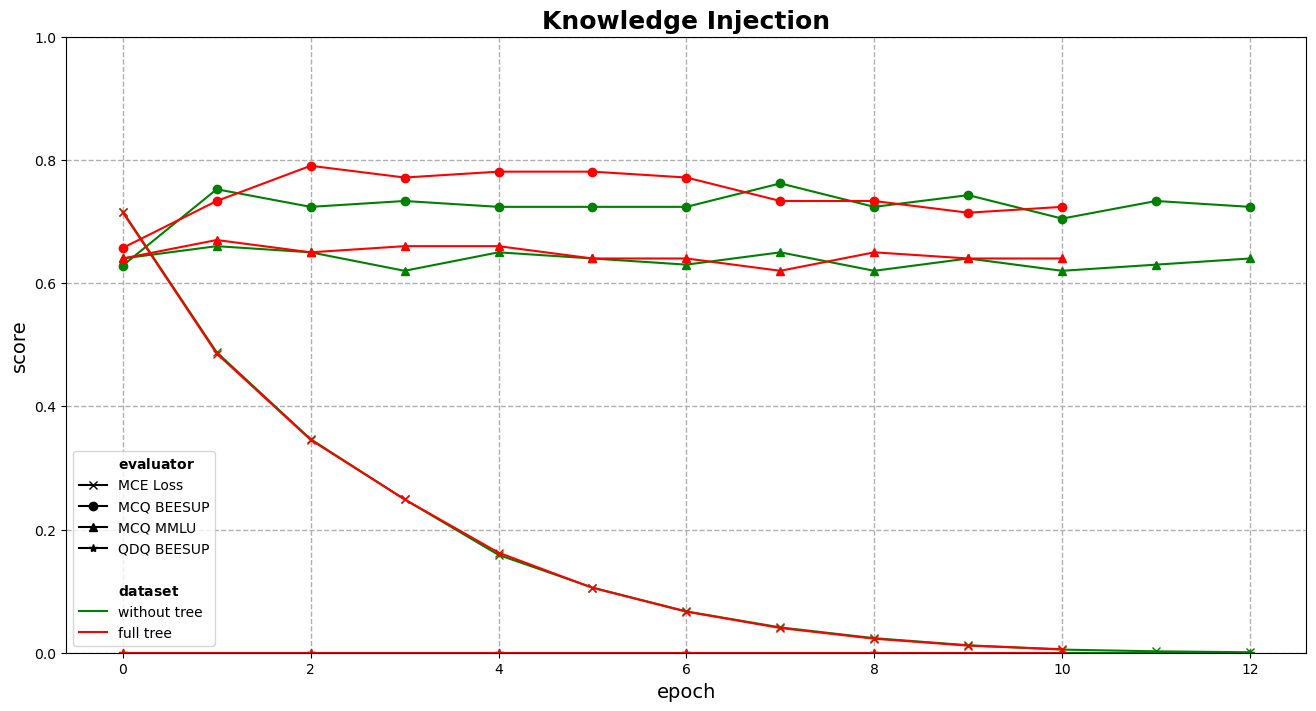

In [76]:
import matplotlib.pyplot as plt

TITLE_FONTSIZE=18
AX_FONTSIZE=14

plt.figure(figsize=(16, 8))

x_col='epoch'
y_col='score'

for i,plot_row in plot_df.iterrows():
    plt.plot(plot_row[x_col],plot_row[y_col],**plot_row['styledict'])

plt.legend(
    handles=get_handles(plot_df),
    #loc='lower right',
    #bbox_to_anchor=(1, 1.0,0.0,0.0),
    #ncol=1,
    #fontsize=AX_FONTSIZE
    )

plt.grid(axis='x', which='major', linestyle='--', linewidth='1.0') #for presentation linewidth='2.0' better
plt.grid(axis='y', which='major', linestyle='--', linewidth='1.0')
plt.grid(axis='y', which='minor', linestyle=':', linewidth='1.0')

plt.ylim(0, 1.0)

plt.title('Knowledge Injection',fontweight='bold',fontsize=TITLE_FONTSIZE)
plt.xlabel(x_col,fontsize=AX_FONTSIZE)
plt.ylabel(y_col,fontsize=AX_FONTSIZE)

plt.show()

## Multiclass Cross Entropy Loss

In [51]:
experiment=InjectionExperiment(14)
experiment.get_config()

2025-02-18 13:04:30,263 - __init__.py - beesup_llm - __init__ - INFO - 0014_INJECTION_EXPERIMENT initialised


2025-02-18 13:04:30,266 - __init__.py - beesup_llm - __init__ - INFO - 0001_LLM_PIPELINE initialised
2025-02-18 13:04:30,268 - __init__.py - beesup_llm - __init__ - INFO - 0003_FINETUNING_PIPELINE initialised
2025-02-18 13:04:30,269 - __init__.py - beesup_llm - __init__ - INFO - 0001_LLM_PIPELINE initialised
2025-02-18 13:04:30,272 - __init__.py - beesup_llm - __init__ - INFO - 0010_DATASET initialised
2025-02-18 13:04:30,294 - __init__.py - beesup_llm - __init__ - INFO - 0003_LLM_EVALUATOR initialised
2025-02-18 13:04:30,297 - __init__.py - beesup_llm - __init__ - INFO - 0004_LLM_EVALUATOR initialised
2025-02-18 13:04:30,300 - __init__.py - beesup_llm - __init__ - INFO - 0005_LLM_EVALUATOR initialised
2025-02-18 13:04:30,302 - __init__.py - beesup_llm - __init__ - INFO - 0006_LLM_EVALUATOR initialised


{'type': 'injection_experiment',
 'id': 14,
 'name': '0014_injection_experiment',
 'dir_name': 'injection_experiments',
 'lab_name': 'injection_lab',
 'rel_path': 'injection_lab/injection_experiments/0014_injection_experiment',
 'done': True,
 'seed': 55,
 'do_eval_base_model': True,
 'do_finetuning': True,
 'remarks': 'tree in training + tree in beesup evaluators!',
 'llm_config': {'type': 'llm_pipeline',
  'id': 1,
  'name': '0001_llm_pipeline',
  'dir_name': 'llm_pipelines',
  'lab_name': 'injection_lab',
  'rel_path': 'injection_lab/llm_pipelines/0001_llm_pipeline',
  'name_or_path': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
  'pipeline_args': {'return_full_text': False,
   'clean_up_tokenization_spaces': True},
  'bnb_config': {'load_in_4bit': True,
   'bnb_4bit_use_double_quant': True,
   'bnb_4bit_quant_type': 'nf4'},
  'inference_tokenizer_config': {'padding_side': 'left',
   'padding': 'longest',
   'max_length': 8192,
   'pad_token': '<|begin_of_text|>',
   'pad_token_id': 128

In [52]:
mce_df=experiment.get_callbacks_df()
mce_df=mce_df[mce_df.evaluator_type=='mce'].dropna(how='all', axis=1).copy()
mce_df.drop(columns=['evaluator_type'], inplace=True)

#mce_df=mce_df.groupby(['global_step']).agg('mean').reset_index()

mce_df

,epoch,global_step,sample_id,loss,batch_proportion
236,0,1,786.0,2.203568,0.228916
237,0,1,897.0,1.390770,0.590361
238,0,1,2230.0,1.714866,0.096386
239,0,1,2926.0,0.361462,0.084337
240,0,2,753.0,1.792487,0.350534
...,...,...,...,...,...
69028,19,16206,3590.0,0.000418,0.653846
69029,19,16207,1458.0,0.000892,0.708683
69030,19,16207,3408.0,0.000053,0.134454
69031,19,16207,2593.0,0.000048,0.042017


In [175]:
mce_df[mce_df.sample_id==786]

,epoch,global_step,sample_id,loss
236,1,0,786.0,1.281549
4607,2,1041,786.0,1.353831
7569,3,1723,786.0,1.919172
13502,4,3155,786.0,1.974331
16964,5,3961,786.0,1.638890
20242,6,4729,786.0,1.460127
22579,7,5255,786.0,1.935778
26237,8,6118,786.0,1.773264
31083,9,7270,786.0,1.167127
34763,10,8139,786.0,2.197363


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plt.plot(log_df['epoch'],log_df['loss'])

In [169]:
log_df=experiment.get_log_history_df()

log_df['epoch']=(log_df['epoch']).astype(int)
log_df=log_df.groupby(['epoch']).agg('mean').reset_index()

log_df

,epoch,loss,grad_norm,learning_rate,step
0,0,1.037136,2.850080,0.000195,426.5
1,1,0.755736,2.613082,0.000185,1279.0
2,2,0.568008,2.822062,0.000175,2132.0
3,3,0.412227,3.026822,0.000165,2985.0
4,4,0.297783,3.037722,0.000155,3838.0
5,5,0.210241,2.891811,0.000145,4691.0
6,6,0.148257,2.563198,0.000135,5544.0
7,7,0.109535,2.476877,0.000125,6397.0
8,8,0.083094,2.290834,0.000115,7250.0
9,9,0.059222,2.040760,0.000105,8103.0


2025-02-17 09:36:07,715 - legend.py - matplotlib.legend - _parse_legend_args - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


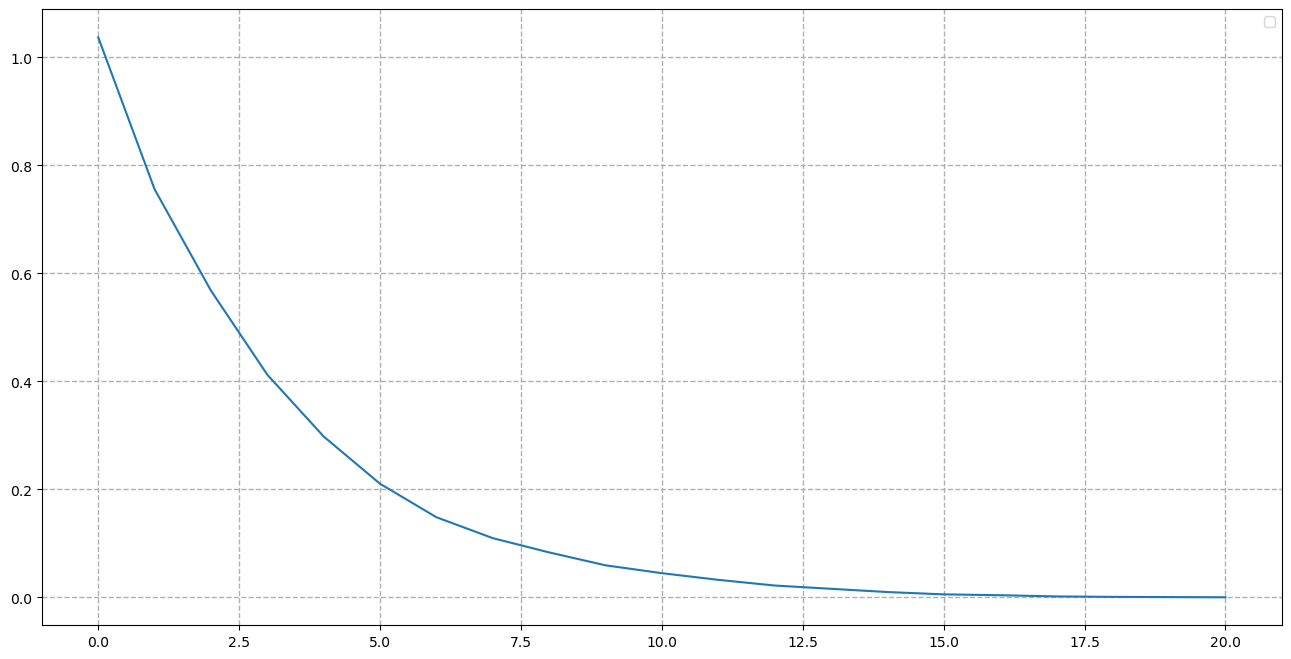

In [170]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 8))
plt.plot(log_df['epoch'],log_df['loss'])
#plt.plot(log_df['epoch'],log_df['learning_rate'])

plt.legend()

plt.grid(axis='x', which='major', linestyle='--', linewidth='1.0') #for presentation linewidth='2.0' better
plt.grid(axis='y', which='major', linestyle='--', linewidth='1.0')
plt.grid(axis='y', which='minor', linestyle=':', linewidth='1.0')

#plt.ylim(0,0.8)

#plt.title('Knowledge Injection',fontweight='bold',fontsize=TITLE_FONTSIZE)
#plt.xlabel(x_col,fontsize=AX_FONTSIZE)
#plt.ylabel(y_col,fontsize=AX_FONTSIZE)

plt.show()


In [ ]:
plot_df=log_df.copy()
#plot_df=plot_df.groupby('epoch').agg('mean').reset_index()
plot_df

,loss,grad_norm,learning_rate,epoch,step
0,1.7014,10.160701,1.999883e-04,0,1
1,1.6101,1.274801,1.999766e-04,0,2
2,1.8166,0.853062,1.999648e-04,0,3
3,1.7485,6.439350,1.999531e-04,0,4
4,1.3266,3.804995,1.999414e-04,0,5
...,...,...,...,...,...
17055,0.0003,0.014004,4.689332e-08,19,17056
17056,0.0002,0.009098,3.516999e-08,19,17057
17057,0.0006,0.023987,2.344666e-08,19,17058
17058,0.0001,0.002510,1.172333e-08,19,17059


In [ ]:
import matplotlib.pyplot as plt

TITLE_FONTSIZE=18
AX_FONTSIZE=14

plt.figure(figsize=(16, 8))


plt.plot(plot_df['epoch'],plot_row[y_col],**plot_row['styledict'])

plt.legend()

plt.grid(axis='x', which='major', linestyle='--', linewidth='1.0') #for presentation linewidth='2.0' better
plt.grid(axis='y', which='major', linestyle='--', linewidth='1.0')
plt.grid(axis='y', which='minor', linestyle=':', linewidth='1.0')

#plt.ylim(0,0.8)

plt.title('Knowledge Injection',fontweight='bold',fontsize=TITLE_FONTSIZE)
plt.xlabel(x_col,fontsize=AX_FONTSIZE)
plt.ylabel(y_col,fontsize=AX_FONTSIZE)

plt.show()



In [19]:
mce_df=callbacks_df[callbacks_df.evaluator_type=='mce'].copy()
mce_df.dropna(how='all', axis=1, inplace=True)
mce_df=mce_df.groupby('sample_id').agg(list).reset_index(drop=False)
mce_df['sample_id']=mce_df['sample_id'].astype(int)


knowledge_df=BaseDataset(6).df

add_cols=['s','p','o']
mce_df=mce_df.merge(knowledge_df[add_cols], left_on='sample_id', right_index=True, how='left')
mce_df

2025-02-14 13:56:02,742 - __init__.py - beesup_llm - __init__ - INFO - 0006_DATASET initialised


,sample_id,global_step,loss,epoch,evaluator_type,s,p,o
0,325,"[1, 3, 6]","[1.2153338193893433, 1.5197525024414062, 1.537...","[1, 2, 3]","[mce, mce, mce]","Andrena fulvida (Schenck, 1853)",Nistweise,endogäisch-selbstgegrabene Hohlräume
1,1561,"[1, 3, 7]","[0.8581979870796204, 1.1004188060760498, 0.674...","[1, 2, 3]","[mce, mce, mce]","Dasypoda hirtipes (Fabricius, 1793)",Umgangssprachliche Bezeichnungen,Dunkelfransige Hosenbiene
2,1750,"[0, 4, 6]","[0.6458176970481873, 0.4610402584075928, 0.730...","[1, 2, 3]","[mce, mce, mce]","Halictus submediterraneus (Pauly, 2015)",Pollensammelverhalten,polylektisch
3,2056,"[1, 3, 7]","[0.8615950345993042, 1.1242815256118774, 0.717...","[1, 2, 3]","[mce, mce, mce]","Hylaeus pictipes (Nylander, 1852)",Pollensammelverhalten,polylektisch (11 Familien)
4,2389,"[0, 4, 6]","[0.6871063709259033, 0.44807371497154236, 0.70...","[1, 2, 3]","[mce, mce, mce]","Lasioglossum parvulum (Schenck, 1853)",Familie,Halictidae
5,2693,"[2, 4, 7]","[7.627578258514404, 7.3950276374816895, 7.5127...","[1, 2, 3]","[mce, mce, mce]","Megachile nigriventris (Schenck, 1870)",Verbreitung,Die Art ist in den Gebirgen Mitteleuropas (bis...
6,2942,"[0, 3, 8]","[0.5408042073249817, 0.5992832779884338, 0.562...","[1, 2, 3]","[mce, mce, mce]","Nomada femoralis (Morawitz, 1869)",Familie,Apidae
7,2995,"[1, 4, 7]","[6.327451705932617, 4.996522426605225, 5.05516...","[1, 2, 3]","[mce, mce, mce]","Nomada fulvicornis (Fabricius, 1793)",Vorkommen und Lebensweise,"Die Art ist in Süd-, Mittel- und dem südlichen..."
8,3135,"[2, 5, 8]","[1.02451753616333, 1.5360527038574219, 1.63111...","[1, 2, 3]","[mce, mce, mce]","Nomada obscura (Zetterstedt, 1838)",Kurzbeschreibung,Nomada obscura ist eine Biene aus der Familie ...
9,3289,"[0, 5, 6]","[0.9544119238853455, 0.9566159844398499, 0.972...","[1, 2, 3]","[mce, mce, mce]","Nomada villosa (Thomson, 1870)",Umgangssprachliche Bezeichnungen,Zottige Wespenbiene


In [34]:
fns=os.listdir(experiment._path)
fns=[fn for fn in fns if 'qdq' in fn]

qdq_df=pd.DataFrame()
for fn in fns:
    df=pd.read_pickle(f"{experiment._path}/{fn}")
    qdq_df=pd.concat([qdq_df,df],ignore_index=True)

qdq_df

,question,target_attr,gold_items,prompt_messages,pred_completion,eval_dict
0,Welche Wildbienen der Familie Megachilidae sam...,Wissenschaftlicher Name,"[Megachile nigriventris (Schenck, 1870), Megac...","[{'role': 'user', 'content': 'You are provided...","Die Wildbienen der Familie Megachilidae, die P...",{'info': 'NotImplemented'}
1,Welche Wildbienen werden umgangssprachlich als...,Wissenschaftlicher Name,"[Andrena pauxilla (E.Stöckhert, 1935), Andrena...","[{'role': 'user', 'content': 'You are provided...",Welche Wildbienen werden umgangssprachlich als...,{'info': 'NotImplemented'}
2,Welche Wildbienen der Familie Halictidae bauen...,Wissenschaftlicher Name,"[Rophites algirus (Pérez, 1895), Rophites quin...","[{'role': 'user', 'content': 'You are provided...","Lasioglossum calcaris (Schulz, 1903); Lasioglo...",{'info': 'NotImplemented'}
3,Welche Wildbienen bauen ihre Nester oberirdisc...,Wissenschaftlicher Name,"[Anthidiellum strigatum (Panzer, 1804), Megach...","[{'role': 'user', 'content': 'You are provided...",Welche Wildbienen bauen ihre Nester oberirdisc...,{'info': 'NotImplemented'}
4,Welche Wildbienen der Familie Halictidae werde...,Wissenschaftlicher Name,"[Halictus langobardicus (Blüthgen, 1944), Hali...","[{'role': 'user', 'content': 'You are provided...",Die Furchenbienen der Familie Halictidae sind:...,{'info': 'NotImplemented'}
...,...,...,...,...,...,...
541,Welche Wildbienen leben solitär und bauen Nest...,Wissenschaftlicher Name,"[Lasioglossum nitidulum (Fabricius, 1804), Las...","[{'role': 'user', 'content': 'You are provided...","Osmia adunca (Panzer, 1798); Osmia leaiana (Ki...",{'info': 'NotImplemented'}
542,Welche Wildbienen haben keine Kuckucksbienen d...,Wissenschaftlicher Name,"[Lasioglossum lativentre (Schenck, 1853), Lasi...","[{'role': 'user', 'content': 'You are provided...","Lasioglossum leucopus (Kirby, 1802); Lasioglos...",{'info': 'NotImplemented'}
543,Welche Wildbienen haben keine Kuckucksbienen d...,Wissenschaftlicher Name,"[Lasioglossum lativentre (Schenck, 1853), Lasi...","[{'role': 'user', 'content': 'You are provided...","Lasioglossum leucopus (Kirby, 1802); Lasioglos...",{'info': 'NotImplemented'}
544,Welche Wildbienen leben sozial und sind Wirtsb...,Wissenschaftlicher Name,"[Lasioglossum morio (Fabricius, 1793), Lasiogl...","[{'role': 'user', 'content': 'You are provided...","Lasioglossum leucopus (Kirby, 1802); Lasioglos...",{'info': 'NotImplemented'}


In [45]:
chars_per_item=len(', '.join(sample.gold_items))/len(sample.gold_items)
chars_per_item

38.8

In [46]:
num_pred_items=len(sample.pred_completion)/chars_per_item
num_pred_items

6.288659793814434

In [ ]:
sample=qdq_df.sample(1).iloc[0]

print(sample.gold_items)
print(sample.pred_completion)

['Lasioglossum morio (Fabricius, 1793)', 'Lasioglossum calceatum (Scopoli, 1763)', 'Lasioglossum malachurum (Kirby, 1802)', 'Lasioglossum laticeps (Schenck, 1870)', 'Lasioglossum pauxillum (Schenck, 1853)']
Lasioglossum leucopus (Kirby, 1802); Lasioglossum minutissimum (Kirby, 1802); Lasioglossum morio (Fabricius, 1793); Lasioglossum punctatissimum (Schenck, 1853); Lasioglossum quadrinotatulum (Schenck, 1861); Lasioglossum villosulum (Kirby, 1802)


## Free Form Questions

In [79]:
knowledge_df=BaseDataset(6).df
knowledge_df.head(2)

2025-02-19 07:53:39,986 - __init__.py - beesup_llm - __init__ - INFO - 0006_DATASET initialised


,s,p,o,source_name,attr_type,n_units,n_words,s_emb,p_emb,o_emb,spo,spo_emb,po,po_emb,so,so_emb
0,"Aglaoapis tridentata (Nylander, 1848)",Aussehen,"Die Biene ist schwarz, etwa 8–10 mm lang und m...",wikipedia,Text,1,33,"[0.009497706, -0.02880746, 0.008733329, 0.0057...","[-0.00241154, 0.018927356, 0.029465966, 0.0016...","[0.01207492, -0.00862774, 0.0006142589, -0.024...","Aglaoapis tridentata (Nylander, 1848)\nAussehe...","[0.017138824, -0.007862857, 0.0062451847, -0.0...","Aussehen\nDie Biene ist schwarz, etwa 8–10 mm ...","[0.013315118, -0.0025690868, -0.002520601, -0....","Aglaoapis tridentata (Nylander, 1848)\nDie Bie...","[0.015632853, -0.013067747, 0.005556736, -0.02..."
1,"Aglaoapis tridentata (Nylander, 1848)",Familie,Megachilidae,wildbienen-kataster,Attribute,1,1,"[0.009497706, -0.02880746, 0.008733329, 0.0057...","[-0.017521149, -0.0039982847, 0.023655187, 0.0...","[-0.009079237, -0.009580155, 0.016292965, 0.01...","Aglaoapis tridentata (Nylander, 1848)\nFamilie...","[0.005252384, -0.036279034, 0.006696027, -0.00...",Familie\nMegachilidae,"[-0.008217988, -0.017626682, 0.014735313, 0.00...","Aglaoapis tridentata (Nylander, 1848)\nMegachi...","[0.006705275, -0.036509484, 0.010870452, -0.00..."


In [80]:
ffq_evals_df=callbacks_df[callbacks_df.evaluator_type=='ffq'].copy()
ffq_evals_df['add_kidc']=ffq_evals_df['add_kidc'].apply(tuple)
ffq_evals_df

group_cols=['experiment_id','question','answer','kidx','add_kidc']
list_cols=['epoch','pred_completion']

ffq_evals_df=ffq_evals_df[group_cols+list_cols].groupby(group_cols).agg(list).reset_index()
ffq_evals_df

,experiment_id,question,answer,kidx,add_kidc,epoch,pred_completion
0,6,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,222.0,(),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Arten der Untergattung Cnemidandrena werd...
1,6,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,3284.0,"(3298, 3194, 2987)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Ich konnte keine genauen Informationen über d...
2,6,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,2022.0,"(2024, 2021)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Maskenbiene Hylaeus nigritus ist eine Art...
3,6,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,3028.0,"(2968,)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Unterscheidung zwischen den Männchen und ...
4,6,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,2943.0,"(1924, 814)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Bienenart Nomada femoralis gehört zur Fam...
5,7,Warum werden die Arten der Untergattung Cnemid...,Die Arten der Untergattung Cnemidandrena werde...,222.0,(),"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Arten der Untergattung Cnemidandrena werd...
6,7,Welche Wirtsarten parasitiert Nomada trapezifo...,Nomada trapeziformis parasitiert vermutlich An...,3284.0,"(3298, 3194, 2987)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Ich konnte keine genauen Informationen über d...
7,7,Wie unterscheiden sich die Männchen und Weibch...,Die Weibchen von Hylaeus nigritus haben eine d...,2022.0,"(2024, 2021)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Maskenbiene Hylaeus nigritus ist eine Art...
8,7,Woran kann man die Männchen und Weibchen von N...,Die Männchen von Nomada guttulata sehen den We...,3028.0,"(2968,)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Unterscheidung zwischen den Männchen und ...
9,7,Zu welcher Familie gehört die Bienenart Nomada...,Nomada femoralis gehört zur Familie der Apidae.,2943.0,"(1924, 814)","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",[Die Bienenart Nomada femoralis gehört zur Fam...


In [46]:
print(knowledge_df.loc[kidc,['s','p','o']].iloc[0].o)

A. denticulata gehört zur Untergattung Cnemidandrena, zu der in Mitteleuropa auch A. freygessneri, A. fuscipes,  A. nigriceps und A. simillima gehören (nicht jedoch die sehr ähnliche A. flavipes). Die Arten der Untergattung Cnemidandrena fliegen alle relativ spät im Jahr, weshalb sie auch Herbstsandbienen genannt werden. 
Im Fernen Osten (Japan, Korea, China und Russland) wurde eine sehr ähnliche Art (A. seneciorum) beschrieben, die teilweise als Unterart (A. denticulata seneciorum) gesehen wird.


In [83]:
sample=ffq_evals_df.iloc[43]

print(f"CHUNKs: ")
kidc=[sample.kidx]+list(sample.add_kidc)
display(knowledge_df.loc[kidc,['s','p','o']])

print(f"QUESTION: {sample.question}\n")
print(f"ANSWER: {sample.answer}\n")
print(25*'#', end='\n\n')

for epoch, pred_completion in zip(sample.epoch, sample.pred_completion):
    print(f"EPOCH {epoch}: {pred_completion.strip()}\n\n")

CHUNKs: 


,s,p,o
3028,"Nomada guttulata (Schenck, 1861)",Merkmale,Die Bienen haben eine Körperlänge von 10 bis 1...
2968,"Nomada flavoguttata (Kirby, 1802)",Merkmale,Die Bienen haben eine Körperlänge von 5 bis 7 ...


QUESTION: Woran kann man die Männchen und Weibchen von Nomada guttulata unterscheiden?

ANSWER: Die Männchen von Nomada guttulata sehen den Weibchen ähnlich, haben jedoch manchmal eine gelbe Zeichnung im Gesicht und ihnen fehlen die gut erkennbaren Dornen auf den Schienen der Hinterbeine, die bei den Weibchen vorhanden sind.

#########################

EPOCH 0: Die Männchen und Weibchen von Nomada guttulata, auch bekannt als Dünen-Steppenbiene, können anhand bestimmter Merkmale unterschieden werden.


EPOCH 2: Die Bienen haben eine Körperlänge von 7 bis 9 Millimetern. Der Kopf und Thorax der Weibchen ist schwarz und ist rot gezeichnet. Die Tergite sind basal schwarz, die Scheiben sind rot, die Hinterränder sind basal schwarz und haben zwei rote Flecken. Das Labrum ist schwarz und trägt mittig ein kleines Zähnchen. Das dritte Fühlerglied ist kürzer als das vierte. Das Schildchen (Scutellum) ist stark gehöckert und hat zwei rote Flecken. Die Schienen (Tibien) der Hinterbeine sind am Ende